# AML Detection with XGBoost and SHAP
### Explainable Transaction Risk Scoring on Imbalanced Financial Data

**Dataset:** IBM Synthetic AML Dataset (5.07M transactions)

**Method:** XGBoost + SHAP

**Context:** revDSG, AMLA (Swiss regulatory frameworks)

---

## Table of Contents
1. Setup
2. Data Loading
3. Exploratory Data Analysis
4. Feature Engineering
5. Time-Based Train/Validation/Test Split
6. Baseline Model: Logistic Regression
7. Main Model: XGBoost
8. Evaluation: AUC-PR, AUC-ROC, Confusion Matrix
9. Threshold Decision
10. Explainability: SHAP
11. Summary

## 1. Setup

In [1]:
# !python3 -m pip install -r requirements.txt

In [ ]:
import random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
	average_precision_score, roc_auc_score,
	precision_recall_curve, roc_curve,
	confusion_matrix, classification_report
)
from tqdm import tqdm

Set seed for reproducibility

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Set plot parameters

In [4]:
plt.rcParams.update({
	'figure.dpi': 120,
	'axes.spines.top': False,
	'axes.spines.right': False,
	'font.family': 'sans-serif'
})

NAVY = '#1B4F72'
LIGHT_BLUE = '#A9CCE3'
ACCENT = '#E74C3C'

In [5]:
print(f'Libraries loaded. Seed set to {SEED}.')

Libraries loaded. Seed set to 42.


## 2. Load dataset

In [6]:
data = load_dataset('eexzzm/IBM-Transactions-for-Anti-Money-Laundering-HI-Small-Trans')
df = data['train'].to_pandas()

print(f'Loaded {len(df)} rows and {df.shape[1]} columns.')

Loaded 5078345 rows and 11 columns.


In [7]:
df = df.rename(columns={'Account': 'From Account', 'Account.1': 'To Account'})

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   From Account        str    
 3   To Bank             int64  
 4   To Account          str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 699.6 MB


In [9]:
df.head(10)

,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0
5,2022/09/01 00:03,1,8000F5AD0,1,8000F5AD0,6162.44,US Dollar,6162.44,US Dollar,Reinvestment,0
6,2022/09/01 00:08,1,8000EBAC0,1,8000EBAC0,14.26,US Dollar,14.26,US Dollar,Reinvestment,0
7,2022/09/01 00:16,1,8000EC1E0,1,8000EC1E0,11.86,US Dollar,11.86,US Dollar,Reinvestment,0
8,2022/09/01 00:26,12,8000EC280,2439,8017BF800,7.66,US Dollar,7.66,US Dollar,Credit Card,0
9,2022/09/01 00:21,1,8000EDEC0,211050,80AEF5310,383.71,US Dollar,383.71,US Dollar,Credit Card,0


## 3. Exploratory Data Analysis

### 3.1 Timestamp distribution

In [10]:
df_eda = df.copy()

# Granulate datetime
df_eda['datetime'] = pd.to_datetime(df_eda['Timestamp'], format='%Y/%m/%d %H:%M')

df_eda['year'] = df_eda['datetime'].dt.year
df_eda['month'] = df_eda['datetime'].dt.month
df_eda['day'] = df_eda['datetime'].dt.day
df_eda['day_of_week'] = df_eda['datetime'].dt.day_name()
df_eda['hour'] = df_eda['datetime'].dt.hour
df_eda['week'] = df_eda['datetime'].dt.isocalendar().week

df_eda['is_off_hours'] = ~df_eda['hour'].between(9, 17)
df_eda['is_weekend']   = df_eda['day_of_week'].isin(['Saturday', 'Sunday'])

In [11]:
# Helper function for time-of-day buckets
def classify_time_of_day(hour: int) -> str:
	if 5 <= hour < 9:
		return '1_EarlyMorning' # 05:00–08:59 — pre-work
	elif 9 <= hour < 12:
		return '2_Morning' # 09:00–11:59 — business hours open
	elif 12 <= hour < 14:
		return '3_Midday' # 12:00–13:59 — lunch window
	elif 14 <= hour < 18:
		return '4_Afternoon' # 14:00–17:59 — business hours core
	elif 18 <= hour < 21:
		return '5_Evening' # 18:00–20:59 — post-work
	elif 21 <= hour < 24:
		return '6_Night' # 21:00–23:59 — late night
	else:
		return '7_Overnight' # 00:00–04:59 — high-risk window


df_eda['time_of_day'] = df_eda['hour'].apply(classify_time_of_day) 

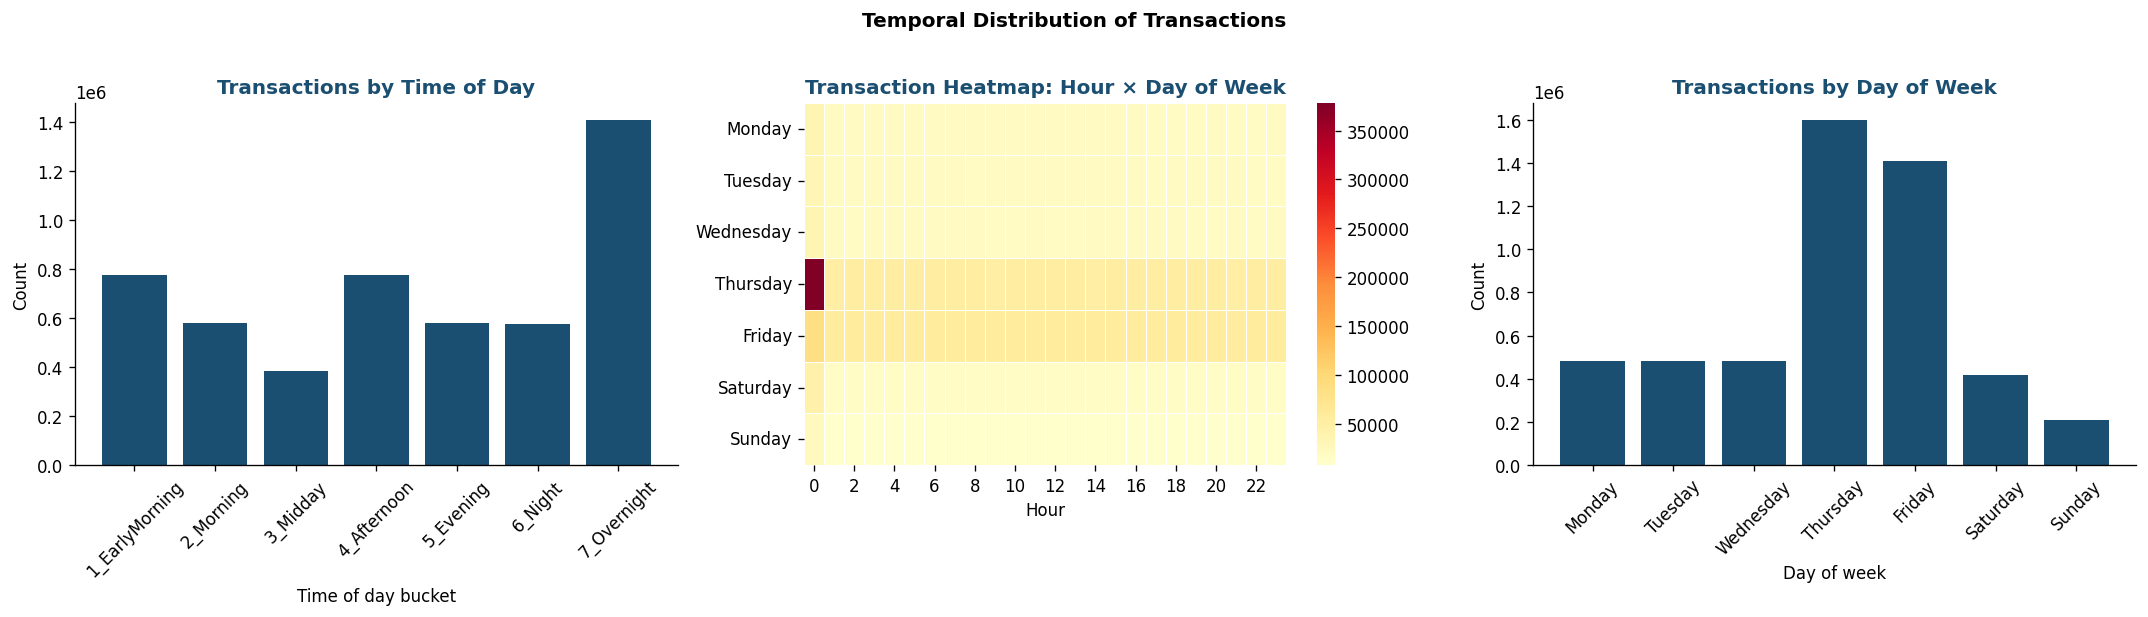

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Time of day
tod_counts = df_eda['time_of_day'].value_counts().sort_index()
axes[0].bar(tod_counts.index, tod_counts.values, color=NAVY)
axes[0].set_title('Transactions by Time of Day', fontweight='bold', color=NAVY)
axes[0].set_xlabel('Time of day bucket')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Hour × Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = df_eda.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(day_order)

sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=axes[1])
axes[1].set_title('Transaction Heatmap: Hour × Day of Week', fontweight='bold', color=NAVY)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('')

# Day of week
dow_counts = df_eda['day_of_week'].value_counts().reindex(day_order)
axes[2].bar(dow_counts.index, dow_counts.values, color=NAVY)
axes[2].set_title('Transactions by Day of Week', fontweight='bold', color=NAVY)
axes[2].set_xlabel('Day of week')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Temporal Distribution of Transactions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

time_of_day
3_Midday          0.001629
4_Afternoon       0.001434
2_Morning         0.001287
1_EarlyMorning    0.001095
5_Evening         0.001071
6_Night           0.000748
7_Overnight       0.000563
Name: Is Laundering, dtype: float64


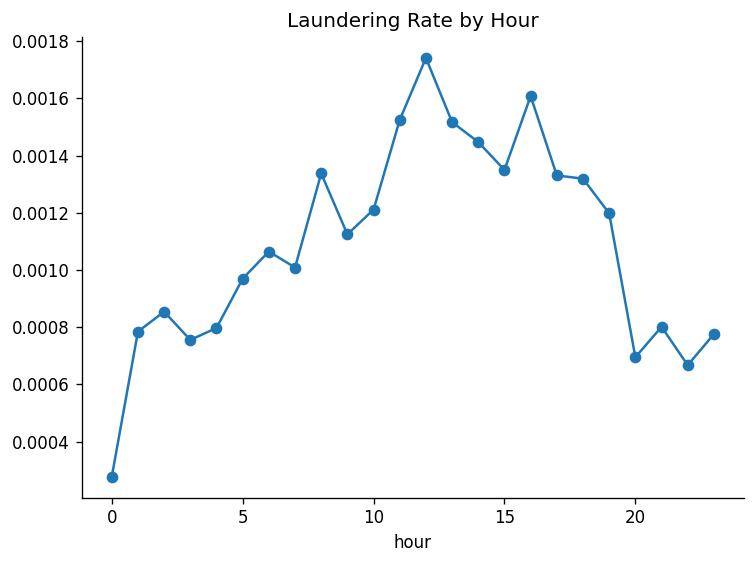

In [13]:
# Fraud rate by time bucket
print(df_eda.groupby('time_of_day')['Is Laundering'].mean().sort_values(ascending=False))

# Fraud rate by hour (good for spotting overnight spikes)
df_eda.groupby('hour')['Is Laundering'].mean().plot(
	kind='line', marker='o', title='Laundering Rate by Hour'
)
plt.tight_layout();
plt.show()

### 3.2 Currency distribution

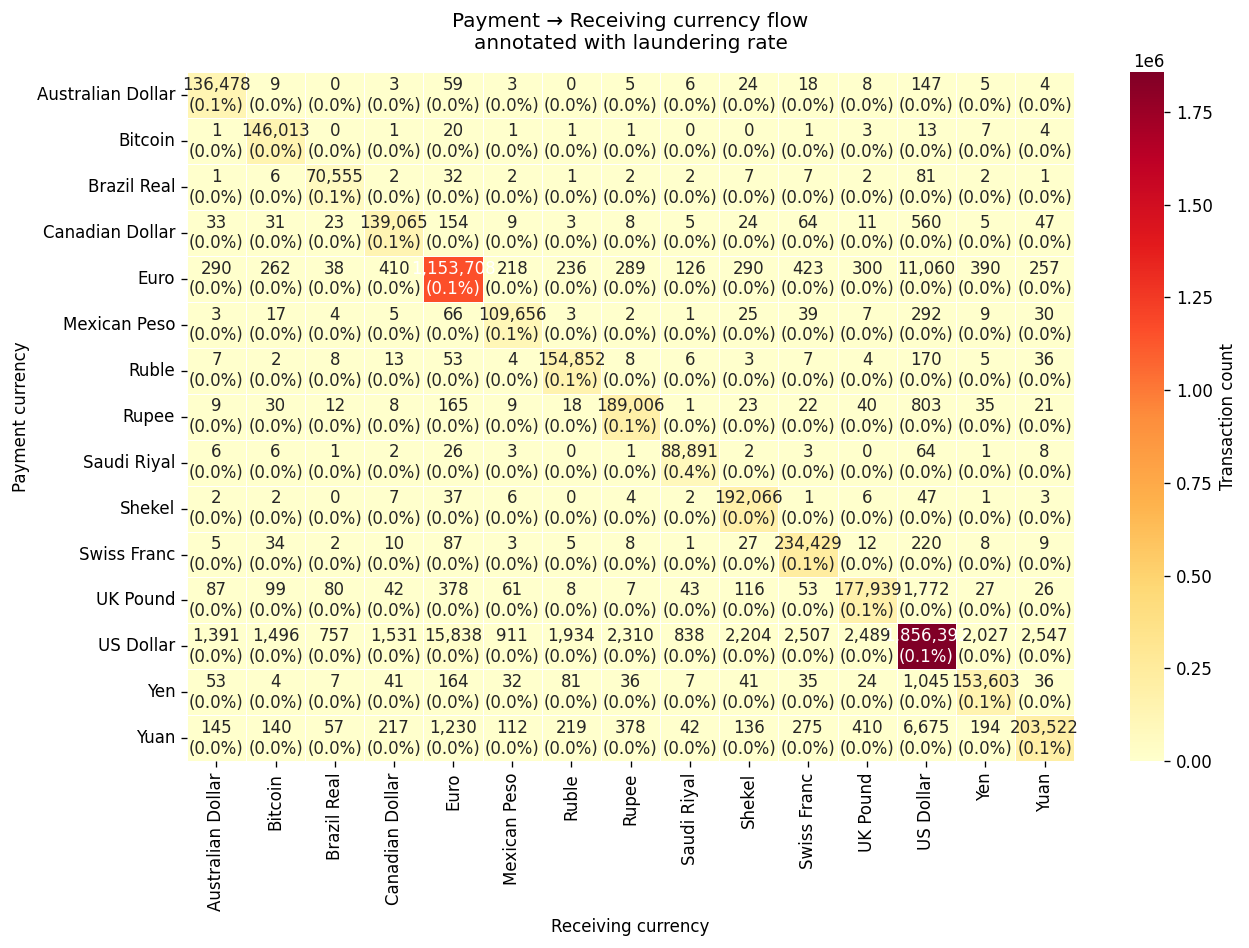

In [14]:
pivot_count = df_eda.groupby(['Payment Currency', 'Receiving Currency']).size().unstack(fill_value=0)

pivot_launder = df_eda.groupby(['Payment Currency', 'Receiving Currency'])['Is Laundering'].mean().unstack(fill_value=0)

annot = pivot_count.copy().astype(object)
for row in pivot_count.index:
	for col in pivot_count.columns:
		count = pivot_count.loc[row, col]
		rate  = pivot_launder.loc[row, col] if row in pivot_launder.index and col in pivot_launder.columns else 0
		annot.loc[row, col] = f'{count:,}\n({rate:.1%})'

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
	pivot_count,
	annot=annot,
	fmt='', # fmt='' because annotations are strings
	cmap='YlOrRd',
	linewidths=0.4,
	linecolor='white',
	ax=ax,
	cbar_kws={'label': 'Transaction count'}
)

ax.set_title('Payment → Receiving currency flow\nannotated with laundering rate', pad=14)
ax.set_xlabel('Receiving currency')
ax.set_ylabel('Payment currency')
plt.tight_layout()
plt.show()

### 3.3 Payment format/currency distribution

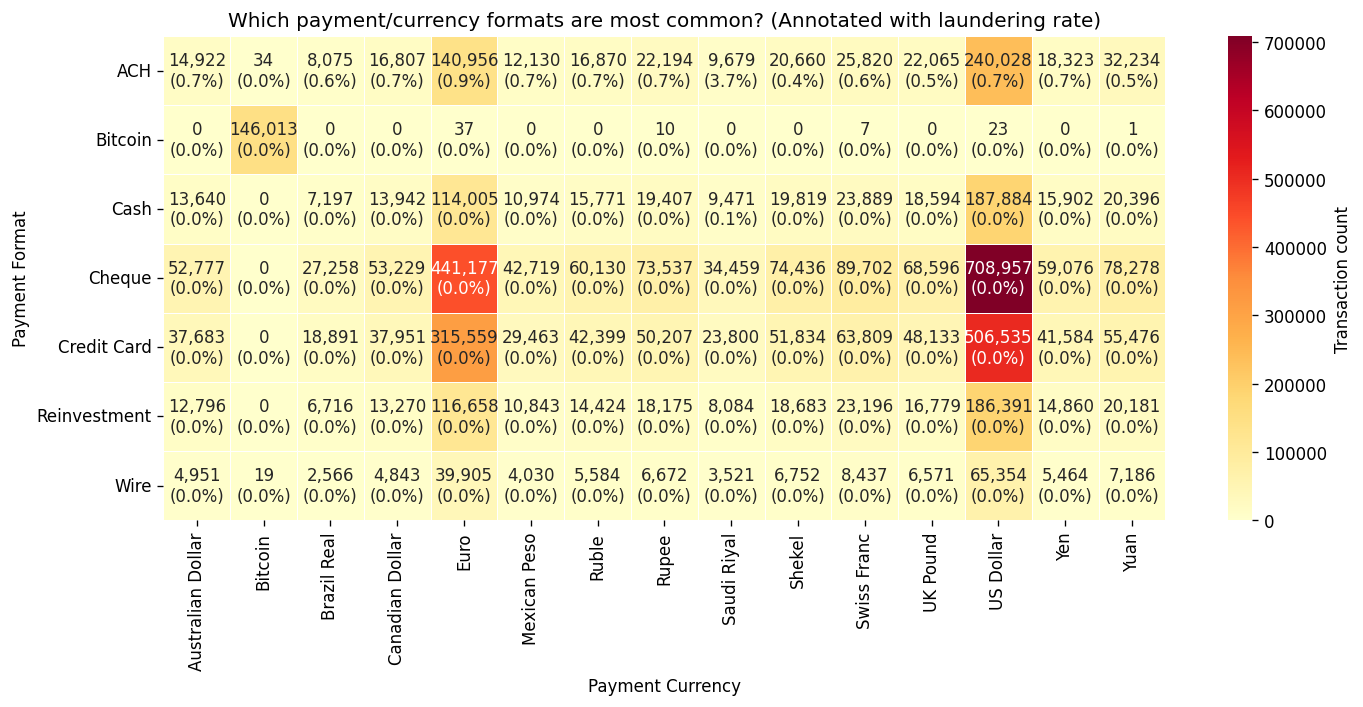

In [15]:
pivot_count = df_eda.groupby(['Payment Format', 'Payment Currency']).size().unstack(fill_value=0)
pivot_launder = df_eda.groupby(['Payment Format', 'Payment Currency'])['Is Laundering'].mean().unstack(fill_value=0)

annot = pivot_count.copy().astype(object)
for row in pivot_count.index:
	for col in pivot_count.columns:
		count = pivot_count.loc[row, col]
		rate  = pivot_launder.loc[row, col] if col in pivot_launder.columns else 0
		annot.loc[row, col] = f'{count:,}\n({rate:.1%})'

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_count, annot=annot, fmt='', cmap='YlOrRd',
	linewidths=0.4, linecolor='white', ax=ax,
	cbar_kws={'label': 'Transaction count'})
ax.set_title('Which payment/currency formats are most common? (Annotated with laundering rate)')
plt.tight_layout()
plt.show();

In [16]:
# Standardize to CHF for exploratory data analysis (multiply below factors by "Amount Paid" to get CHF equivalent)
rates_to_chf = {
	'US Dollar': 0.9729,
	'Euro': 0.9642,
	'UK Pound': 1.1035,
	'Australian Dollar': 0.6504,
	'Canadian Dollar': 0.7309,
	'Yuan': 0.138548,
	'Yen': 0.006808,
	'Rupee': 0.01218,
	'Mexican Peso': 0.048474,
	'Ruble': 0.0162,
	'Brazil Real': 0.186205,
	'Saudi Riyal': 0.25944,
	'Shekel': 0.2742,
	'Swiss Franc': 1.0,
	'Bitcoin': 20246.0
}

df_eda['Amount Paid CHF'] = df_eda['Amount Paid'] * df_eda['Payment Currency'].map(rates_to_chf)
print(df_eda['Amount Paid CHF'].describe())
print(f"\nSkewness: {df_eda['Amount Paid CHF'].skew():.2f}")
print(f"% transactions > 100k CHF: {(df_eda['Amount Paid CHF'] > 100_000).mean():.1%}")

count    5.078345e+06
mean     3.337593e+05
std      2.380304e+07
min      6.808000e-05
25%      1.476409e+02
50%      8.359741e+02
75%      4.997121e+03
max      2.792390e+10
Name: Amount Paid CHF, dtype: float64

Skewness: 589.23
% transactions > 100k CHF: 6.5%


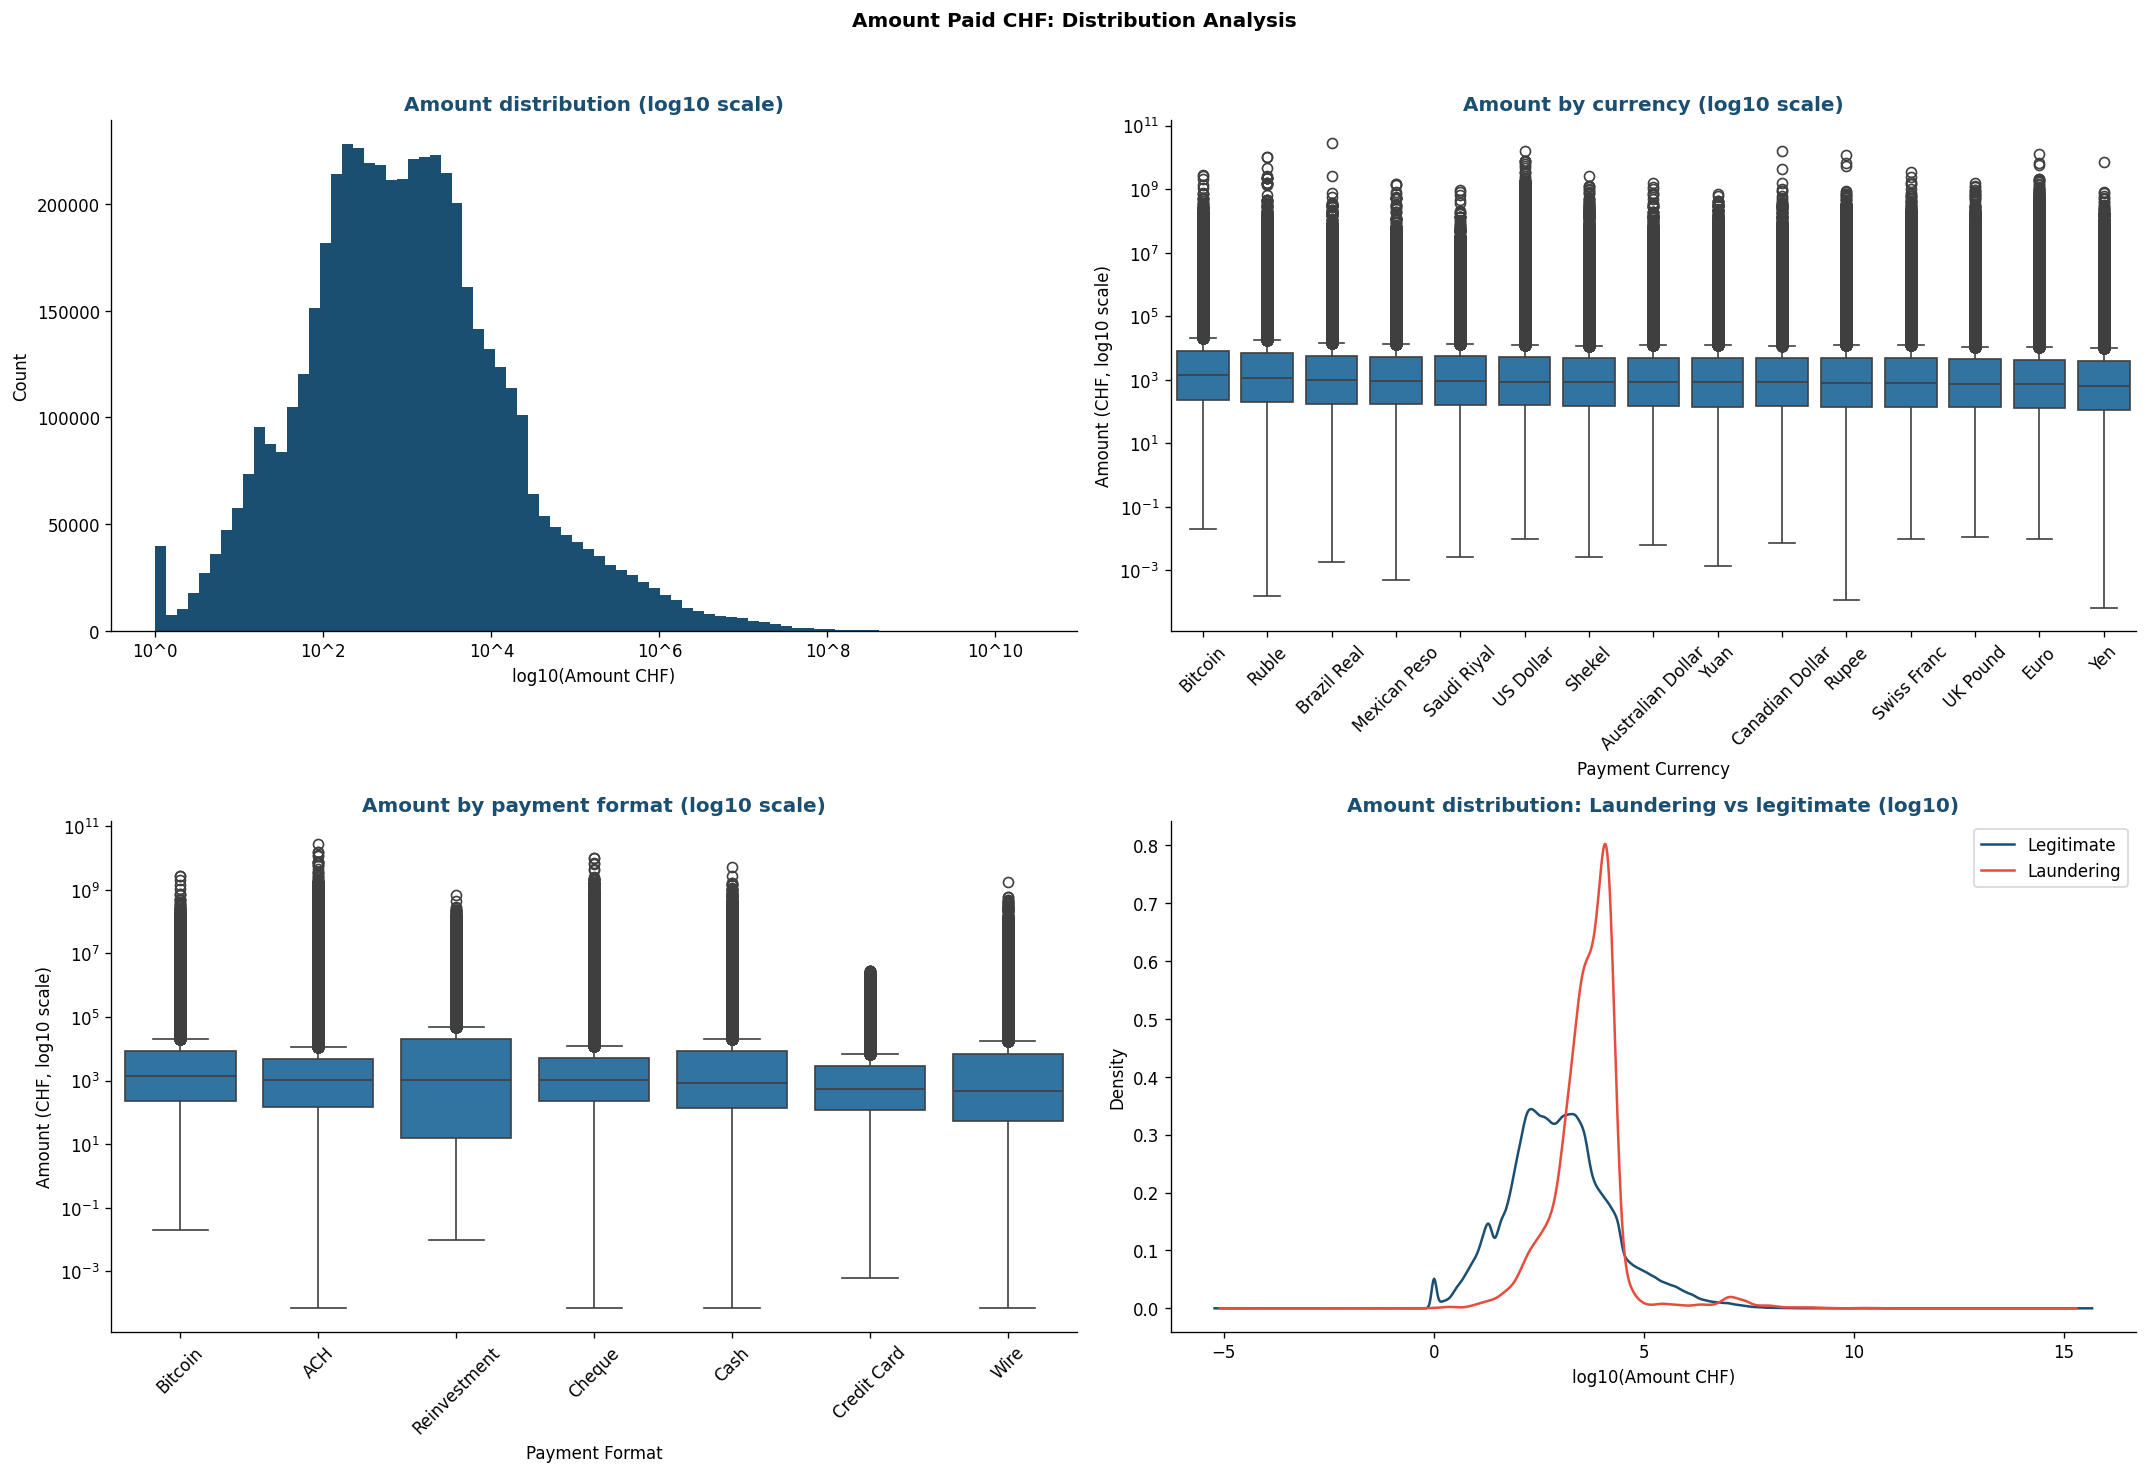

                   count          mean           std       min          25%  \
Is Laundering                                                                 
0              5073168.0  3.290453e+05  2.272444e+07  0.000068   147.392494   
1                 5177.0  4.953199e+06  2.230091e+08  0.318186  1972.451075   

                       50%           75%           max  
Is Laundering                                           
0               833.814216   4984.423478  2.792390e+10  
1              5508.410000  12495.197925  1.571486e+10  


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Amount distribution, standardized to CHF (log10 histogram)
np.log10(df_eda['Amount Paid CHF'].clip(lower=1)).plot(kind='hist', bins=80, ax=axes[0, 0], color=NAVY)
axes[0, 0].set_title('Amount distribution (log10 scale)', fontweight='bold', color=NAVY)
axes[0, 0].set_xlabel('log10(Amount CHF)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels([f'10^{int(x)}' for x in axes[0, 0].get_xticks()])

# Amount by currency, standardized to CHF (boxplot)
order_currency = df_eda.groupby('Payment Currency')['Amount Paid CHF'].median().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x='Payment Currency', y='Amount Paid CHF',
			order=order_currency, showfliers=True, ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Amount by currency (log10 scale)', fontweight='bold', color=NAVY)
axes[0, 1].set_xlabel('Payment Currency')
axes[0, 1].set_ylabel('Amount (CHF, log10 scale)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Amount by payment format, standardized to CHF (boxplot)
order_format = df_eda.groupby('Payment Format')['Amount Paid CHF'].median().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x='Payment Format', y='Amount Paid CHF',
			order=order_format, showfliers=True, ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Amount by payment format (log10 scale)', fontweight='bold', color=NAVY)
axes[1, 0].set_xlabel('Payment Format')
axes[1, 0].set_ylabel('Amount (CHF, log10 scale)')
axes[1, 0].tick_params(axis='x', rotation=45)

# KDE: laundering vs legitimate
for label, grp in df_eda.groupby('Is Laundering'):
	np.log10(grp['Amount Paid CHF'].clip(lower=1)).plot(
		kind='kde', ax=axes[1, 1],
		label='Laundering' if label == 1 else 'Legitimate',
		color=ACCENT if label == 1 else NAVY
	)
axes[1, 1].set_title('Amount distribution: Laundering vs legitimate (log10)', fontweight='bold', color=NAVY)
axes[1, 1].set_xlabel('log10(Amount CHF)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

plt.suptitle('Amount Paid CHF: Distribution Analysis', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quick stats: kept separate as tabular output, not a plot
print(df_eda.groupby('Is Laundering')['Amount Paid CHF'].describe())

### 3.4 Class distribution

In [18]:
# Class distribution
counts_laundering = df_eda['Is Laundering'].value_counts()
rate_laundering = df_eda['Is Laundering'].mean()

print(f'Legitimate transactions: {counts_laundering[0]:>10,} ({1 - rate_laundering:.4%})')
print(f'Laundering transactions: {counts_laundering[1]:>10,} ({rate_laundering:.4%})')
print(f'Class imbalance: {counts_laundering[0] / counts_laundering[1]:.0f}:1')
print(f'=> `scale_pos_weight`: {counts_laundering[0] / counts_laundering[1]:.2f}')

Legitimate transactions:  5,073,168 (99.8981%)
Laundering transactions:      5,177 (0.1019%)
Class imbalance: 980:1
=> `scale_pos_weight`: 979.94


In [19]:
# Compute fraud rate by payment format
format_fraud = (
	df_eda.groupby('Payment Format')['Is Laundering']
	.agg(['mean', 'count'])
	.rename(columns={'mean': 'fraud_rate', 'count': 'n'})
	.sort_values('fraud_rate', ascending=False)
)

daily = (
	df_eda.assign(Timestamp=pd.to_datetime(df_eda['Timestamp']))
	.set_index('Timestamp')
	.groupby(pd.Grouper(freq='D'))['Is Laundering']
	.agg(['sum', 'count'])
	.rename(columns={'sum': 'laundering', 'count': 'total'})
)
daily['fraud_rate'] = daily['laundering'] / daily['total']

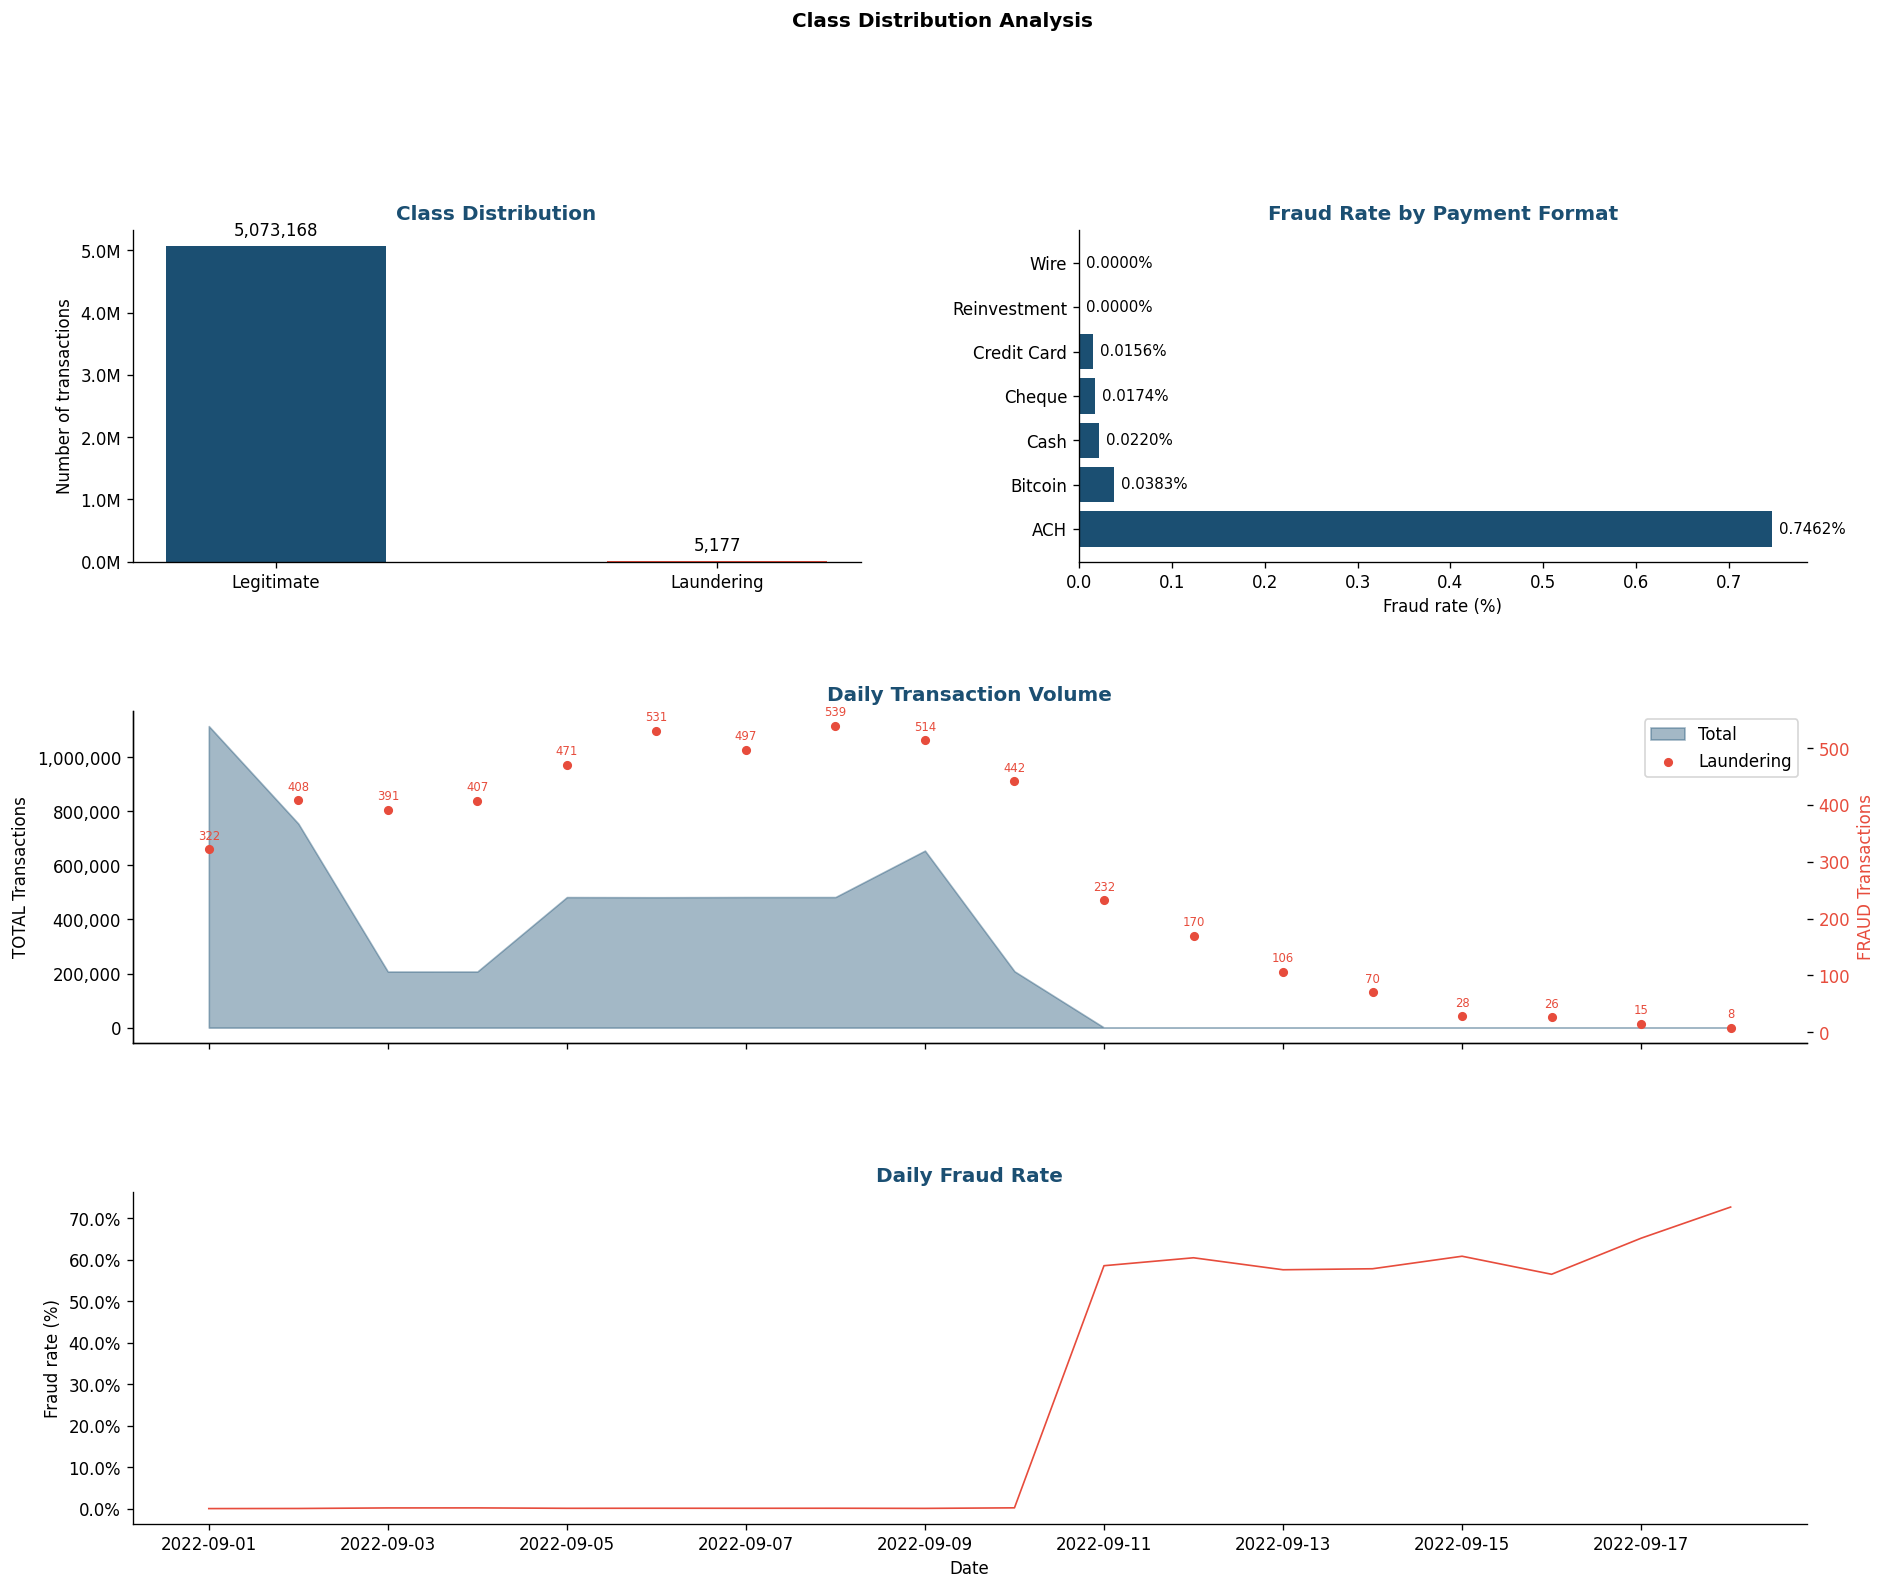

                fraud_rate        n
Payment Format                     
ACH               0.007462   600797
Bitcoin           0.000383   146091
Cash              0.000220   490891
Cheque            0.000174  1864331
Credit Card       0.000156  1323324
Reinvestment      0.000000   481056
Wire              0.000000   171855


In [20]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0]) # Graph 1: class distribution bar
ax2 = fig.add_subplot(gs[0, 1]) # Graph 2: fraud rate by format
ax3a = fig.add_subplot(gs[1, :]) # Graph 3 top: daily volume
ax3b = fig.add_subplot(gs[2, :], sharex=ax3a) # Graph 3 bottom: daily fraud rate

### Class distribution
bars = ax1.bar(['Legitimate', 'Laundering'], counts_laundering.values, color=[NAVY, ACCENT], width=0.5)
ax1.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=10)
ax1.set_ylabel('Number of transactions')
ax1.set_title('Class Distribution', fontweight='bold', color=NAVY)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

### Fraud rate by payment format
bars2 = ax2.barh(format_fraud.index, format_fraud['fraud_rate'] * 100, color=NAVY)
ax2.bar_label(bars2, fmt='{:.4f}%', padding=4, fontsize=9)
ax2.set_xlabel('Fraud rate (%)')
ax2.set_title('Fraud Rate by Payment Format', fontweight='bold', color=NAVY)

### Daily transaction volume
ax3a.fill_between(daily.index, daily['total'], color=NAVY, alpha=0.4, label='Total')
ax3a.set_ylabel('TOTAL Transactions')
ax3a.set_title('Daily Transaction Volume', fontweight='bold', color=NAVY)
ax3a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.setp(ax3a.get_xticklabels(), visible=False)

# Laundering as scatter points on a secondary y-axis so it's not dwarfed
ax3a_r = ax3a.twinx()
ax3a_r.scatter(daily.index, daily['laundering'], color=ACCENT, s=20, zorder=5, label='Laundering')

# Data labels — only label days where laundering > 0 to avoid clutter
for date, row in daily[daily['laundering'] > 0].iterrows():
	ax3a_r.annotate(
		f'{int(row["laundering"])}',
		xy=(date, row['laundering']),
		xytext=(0, 6),
		textcoords='offset points',
		ha='center', fontsize=7, color=ACCENT
	)
ax3a_r.set_ylabel('FRAUD Transactions', color=ACCENT)
ax3a_r.tick_params(axis='y', labelcolor=ACCENT)

# Combined legend
lines1, labels1 = ax3a.get_legend_handles_labels()
lines2, labels2 = ax3a_r.get_legend_handles_labels()
ax3a.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Daily fraud rate
ax3b.plot(daily.index, daily['fraud_rate'] * 100, color=ACCENT, linewidth=1)
ax3b.set_ylabel('Fraud rate (%)')
ax3b.set_xlabel('Date')
ax3b.set_title('Daily Fraud Rate', fontweight='bold', color=NAVY)
ax3b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.suptitle('Class Distribution Analysis', fontweight='bold', y=1.01)
plt.show()

print(format_fraud)

## 4. Feature Engineering

### Why these features?

#### A note on the three stages of money laundering

Money laundering typically follows three stages: **placement** (entering the financial system), **layering** (obscuring the trail), and **integration** (re-entering the legitimate economy) ([UN Office on Drugs and Crime](https://www.unodc.org/unodc/en/money-laundering/overview.html)). Most transaction-level signals target the **layering** stage, where suspicious patterns are most detectable in the data. The features below are designed with this in mind.

Feature engineering is done in two steps, both on the full dataset before the train/val/test split:

1. **Account-level rolling features** (`add_rolling_features`): aggregate
	each account's historical behavior over the prior 7 and 30 days. These
	must be computed pre-split because they look across rows; computing them
	post-split would produce incorrect window calculations at split boundaries.

2. **Row-wise features** (`engineer_features`): transformations that depend
	only on a single transaction's own columns (amounts, timestamps, currencies,
	banks). These are split-agnostic but computed here for notebook clarity.

### 4.1 Account-level rolling features

These features capture *behavioral change over time* at the account level: a dimension that single-transaction features cannot access. The core intuition is that laundering is rarely a single anomalous transaction; it is a pattern of behavior. An account that suddenly sends 50 transactions in 7 days, or whose average amount spikes 500x above its 30-day baseline, is exhibiting a pattern consistent with layering regardless of whether any individual transaction looks suspicious in isolation.

For each transaction at time $t$, only transactions strictly before $t$ are used (via `shift(1)` within each account group) so that no row sees its own data ("rolling" includes the current day, back to and including 6 days prior). This is essential: including the current transaction in its own rolling window would contaminate the baseline it is supposed to be compared against.

**Transaction count** (`acct_txn_count_7d`, `acct_txn_count_30d`): how many transactions this account sent in the prior 7 and 30 days. A sudden spike in frequency is consistent with smurfing, the phenomenon of structuring many small transactions to stay below reporting thresholds (Han et al., 2020).

**Amount sum** (`acct_amount_sum_7d`, `acct_amount_sum_30d`): total value sent in the window. Captures rapid accumulation or dispersal of funds.

**Amount mean** (`acct_amount_mean_7d`, `acct_amount_mean_30d`): average transaction size. Sensitive to outliers.

**Amount median** (`acct_amount_med_7d`, `acct_amount_med_30d`): the account's typical transaction size, robust to outliers. Used alongside the mean: a large gap between mean and median indicates at least one extreme transaction in the window.

**Amount std** (`acct_amount_std_7d`, `acct_amount_std_30d`): volatility of transaction sizes. Unusual variance, i.e. either very high or suddenly spiking, can indicate a change in account behavior.

**Amount max** (`acct_amount_max_7d`, `acct_amount_max_30d`): the largest single transaction in the window. Complements the median: together they give the model both the typical baseline and the worst-case deviation.

In [ ]:
def add_rolling_features(df: pd.DataFrame) -> pd.DataFrame:
	"""
	Compute account-level behavioral features using only past transactions.
	`df` must be sorted by Timestamp before calling this function.
	
	For each transaction, we look back at the sending account's history over the prior 7 days and 30 days.
	No future data is used, which is safe against temporal leakage.
	"""
	df = df.copy()
	df['Timestamp'] = pd.to_datetime(df['Timestamp']) # Ensure pandas datetime
	df = df.sort_values('Timestamp').reset_index(drop=True) # Sort chronologically since we are only looking at past values
	df['_txn_idx'] = df.index # Unique row identifier

	minimal_df = df[['_txn_idx', 'From Account', 'Timestamp', 'Amount Paid']].copy() # Only necessary columns for behavioral analysis - to save on computational load
	minimal_df = minimal_df.set_index('Timestamp')

	results = []
	for _, group in tqdm(list(minimal_df.groupby('From Account')), desc='Computing rolling features', unit='Account'):
		group = group.sort_index()

		r7 = group['Amount Paid'].rolling('7D') # Transactions from time t back to and including t-6
		r30 = group['Amount Paid'].rolling('30D')

		result = pd.DataFrame({
			'_txn_idx': group['_txn_idx'].values,
			'acct_txn_count_7d': r7.count().values,
			'acct_amount_sum_7d': r7.sum().values,
			'acct_amount_mean_7d': r7.mean().values,
			'acct_amount_med_7d': r7.median().values,
			'acct_amount_max_7d': r7.max().values,
			'acct_amount_std_7d': r7.std().fillna(0).values,
			'acct_txn_count_30d': r30.count().values,
			'acct_amount_sum_30d': r30.sum().values,
			'acct_amount_mean_30d': r30.mean().values,
			'acct_amount_med_30d': r30.median().values,
			'acct_amount_max_30d': r30.max().values,
			'acct_amount_std_30d': r30.std().fillna(0).values
		})

		# Shift by +1 within account so that each row only sees past transactions (since "rolling" includes that day)
		# First row of each account gets 0 (no prior history)
		result.iloc[:, 1:] = result.iloc[:, 1:].shift(1).fillna(0)
		results.append(result)
	
	rolling_df = pd.concat(results).reset_index(drop=True)

	df = df.merge(rolling_df, on='_txn_idx', how='left')
	df = df.drop(columns='_txn_idx')

	return df

### 4.2 Row-wise features

#### 4.2.1 Temporal features: `hour`, `day_of_week`, `is_weekend`, `time_of_day`

Legitimate financial activity follows predictable rhythms: most transactions occur during business hours on weekdays. Layering activity is often deliberately timed to avoid scrutiny: late-night transfers, weekend movements, or transactions structured to fall outside normal monitoring windows. These temporal features are motivated by the broader AML layering literature (Han et al., 2020; Di Gennaro et al., 2025) rather than a specific regulatory citation.
* `hour` gives the model fine-grained time information
* `time_of_day` buckets this into early morning, morning, midday, afternoon, evening, night, and overnight; capturing the conceptual signal more cleanly and making SHAP explanations more human-interpretable
	* Both `hour` and `time_of_day` are included since `XGBoost` can determine which is more predictive
* `is_weekend` flags Saturday and Sunday transactions, which are atypical for institutional transfers and warrant extra scrutiny

#### 4.2.2 Amount features: `log_amount_paid`, `log_amount_received`

Raw transaction amounts are heavily right-skewed: a few very large transactions dominate the scale and make it harder for the model to learn from the majority of smaller ones. Log-transforming (via `log1p` to handle zeros) compresses this range and gives the model a more learnable signal across the full distribution. This is standard preprocessing for financial transaction data.

#### 4.2.3 `amount_diff`

The absolute difference between what was paid and what was received. For a clean transfer this should be small, typically just a transaction fee. Large differences can indicate that value is being extracted or injected at each step in a layering chain, or that currency conversion is being used to obscure amounts.

#### 4.2.4 `amount_ratio`

`Amount Sent` divided by `Amount Received`. Legitimate transfers are typically close to 1-to-1: the recipient receives what was sent, minus a small fee. Launderers deliberately distort amounts across transaction chains to make the money trail harder to follow, a technique sometimes combined with smurfing (structuring many small transactions to stay below reporting thresholds) or round-tripping (routing funds through multiple jurisdictions and back) (Han et al., 2020). A ratio significantly above or below 1 is therefore a soft but meaningful signal of layering behavior. Clipped at 100 to prevent extreme outliers from dominating the feature space.

#### 4.2.5 `cross_currency`

A binary flag for transactions where the payment currency differs from the receiving currency. The [FFIEC BSA/AML Examination Manual (Appendix F, Funds
Transfers)](https://bsaaml.ffiec.gov/docs/manual/10_Appendices/07.pdf) explicitly lists funds transfer activity to or from higher-risk geographic locations "without an apparent business reason" as a red flag: cross-currency transactions are a structural proxy for this cross-border complexity and the added tracing difficulty it introduces.

#### 4.2.6 `same_bank`

A binary flag for transactions where the sending and receiving bank are the same institution. Same-bank transfers that are flagged as suspicious suggest internal layering rather than cross-border movement. This feature is motivated by the broader layering literature, though less directly documented than cross-currency signals.

#### 4.2.7 Categorical encodings: `payment_format_enc`, `pay_currency_enc`, `rec_currency_enc`

Payment format carries meaningful risk signal. The [FFIEC BSA/AML Examination Manual (Section: Risks Associated with Money Laundering — Funds Transfers,
"Risk Mitigation")](https://bsaaml.ffiec.gov/docs/manual/09_RisksAssociatedWithMoneyLaunderingAndTerroristFinancing/07.pdf) states explicitly that "funds transfers can be used in the placement, layering, and integration stages of money laundering", identifying them as a high-risk instrument warranting dedicated monitoring controls. Label encoding converts these categorical variables into a numeric form that `XGBoost` can use directly: unlike one-hot encoding, this avoids expanding the feature space unnecessarily for a tree-based model.

In [22]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
	df = df.copy()

	# Temporal features
	df['hour'] = df['Timestamp'].dt.hour
	df['day_of_week'] = df['Timestamp'].dt.dayofweek
	df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
	df['time_of_day_enc'] = df['hour'].apply(classify_time_of_day).astype('category').cat.codes # Time-of-day buckets (ordered + label-encoded)

	# Amount features
	df['log_amount_paid'] = np.log1p(df['Amount Paid'])
	df['log_amount_received'] = np.log1p(df['Amount Received'])
	df['amount_ratio'] = (df['Amount Paid'] / (df['Amount Received'] + 1e-9)).clip(0, 100)
	df['amount_diff'] = df['Amount Paid'] - df['Amount Received']

	# Cross-currency flag
	df['cross_currency'] = (df['Payment Currency'] != df['Receiving Currency']).astype(int)

	# Bank flags
	df['from_bank_enc'] = df['From Bank'].astype('category').cat.codes
	df['to_bank_enc']   = df['To Bank'].astype('category').cat.codes
	df['same_bank'] = (df['From Bank'] == df['To Bank']).astype(int)

	# Categorical encoding
	df['payment_format_enc'] = df['Payment Format'].astype('category').cat.codes
	df['pay_currency_enc'] = df['Payment Currency'].astype('category').cat.codes
	df['rec_currency_enc'] = df['Receiving Currency'].astype('category').cat.codes

	return df

### 4.3 Apply features

Finally, apply the feature engineering functions to the full dataset (prior to splitting into train/validation/test sets).

In [23]:
df = add_rolling_features(df)

Computing rolling features: 100%|██████████| 496995/496995 [09:07<00:00, 907.03Account/s] 


In [24]:
df = engineer_features(df)

In [25]:
print('Feature engineering complete.\n')
print(df.info())

Feature engineering complete.

<class 'pandas.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 38 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Timestamp             datetime64[us]
 1   From Bank             int64         
 2   From Account          str           
 3   To Bank               int64         
 4   To Account            str           
 5   Amount Received       float64       
 6   Receiving Currency    str           
 7   Amount Paid           float64       
 8   Payment Currency      str           
 9   Payment Format        str           
 10  Is Laundering         int64         
 11  acct_txn_count_7d     float64       
 12  acct_amount_sum_7d    float64       
 13  acct_amount_mean_7d   float64       
 14  acct_amount_med_7d    float64       
 15  acct_amount_max_7d    float64       
 16  acct_amount_std_7d    float64       
 17  acct_txn_count_30d    float64       
 18  acct_amount_sum_30d   

## 5. Time-Based Train/Validation/Test Split

We use a **time-based split (70/15/15)** rather than a random split.

With a random split, the model would be trained on transactions from across the entire time range, including periods *after* the validation and test cutoffs. This means future laundering patterns leak into training, and the model gets credit for "detecting" behavior it has effectively already seen. In AML, where the objective is generalizing to *future* suspicious behavior, this produces artificially inflated evaluation metrics and a false sense of model quality.

A time-based split is the honest choice: the model only ever trains on the past and is evaluated on what comes after. This better reflects real deployment conditions, where a model trained today will be scored against tomorrow's transactions.

**Note on fraud rate distribution:** The IBM synthetic dataset concentrates laundering activity in certain time windows rather than distributing it uniformly. As a result, fraud rates may differ noticeably across splits (see output below). If the training set has a significantly lower fraud rate than the test set, this is worth noting as a limitation: the model is being evaluated on a distribution shift, which is realistic (fraud patterns do evolve), but should be interpreted carefully.

The split is already deterministic (sorted by timestamp), so no random seed is needed for the split itself. The global `SEED` defined above covers all downstream randomness.

Train      |  3,554,841 rows| 2022-09-01 -> 2022-09-07 | fraud rate: 0.0803%
Validation |    761,752 rows| 2022-09-07 -> 2022-09-09 | fraud rate: 0.0998%
Test       |    761,752 rows| 2022-09-09 -> 2022-09-18 | fraud rate: 0.2049%


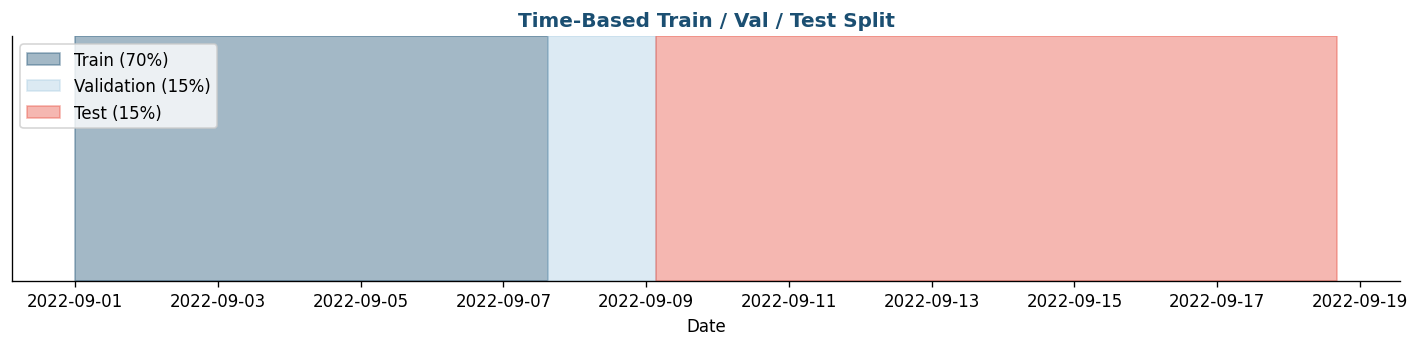

In [26]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
val = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

for name, split in [('Train', train), ('Validation', val), ('Test', test)]:
	print(
		f'{name:<10} | {len(split):>10,} rows'
		f'| {split["Timestamp"].min().date()} -> {split["Timestamp"].max().date()} '
		f'| fraud rate: {split["Is Laundering"].mean():.4%}'
	)

# Visualize split boundaries over time
fig, ax = plt.subplots(figsize=(12, 3))

for split, color, label in [
	(train, NAVY, 'Train (70%)'),
	(val, LIGHT_BLUE, 'Validation (15%)'),
	(test, ACCENT, 'Test (15%)'),
]:
	ax.axvspan(split['Timestamp'].min(), split['Timestamp'].max(), alpha=0.4, color=color, label=label)

ax.set_xlabel('Date')
ax.set_yticks([])
ax.set_title('Time-Based Train / Val / Test Split', fontweight='bold', color=NAVY)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [27]:
FEATURES = [
	'log_amount_paid', 'log_amount_received', 'amount_ratio', 'amount_diff',
	'hour', 'day_of_week', 'is_weekend', 'time_of_day_enc',
	'same_bank', 'from_bank_enc', 'to_bank_enc',
	'payment_format_enc', 'pay_currency_enc', 'rec_currency_enc', 'cross_currency',
	# Rolling account-level features
	'acct_txn_count_7d', 'acct_amount_sum_7d', 'acct_amount_mean_7d', 'acct_amount_med_7d', 'acct_amount_max_7d', 'acct_amount_std_7d',
	'acct_txn_count_30d', 'acct_amount_sum_30d', 'acct_amount_mean_30d', 'acct_amount_med_30d', 'acct_amount_max_30d', 'acct_amount_std_30d'
]
TARGET = 'Is Laundering'

X_train, y_train = train[FEATURES], train[TARGET]
X_val, y_val = val[FEATURES], val[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f'Features: {FEATURES}')
print(f'\nTrain: {X_train.shape}')
print(f'Validation: {X_val.shape}')
print(f'Test: {X_test.shape}')

Features: ['log_amount_paid', 'log_amount_received', 'amount_ratio', 'amount_diff', 'hour', 'day_of_week', 'is_weekend', 'time_of_day_enc', 'same_bank', 'from_bank_enc', 'to_bank_enc', 'payment_format_enc', 'pay_currency_enc', 'rec_currency_enc', 'cross_currency', 'acct_txn_count_7d', 'acct_amount_sum_7d', 'acct_amount_mean_7d', 'acct_amount_med_7d', 'acct_amount_max_7d', 'acct_amount_std_7d', 'acct_txn_count_30d', 'acct_amount_sum_30d', 'acct_amount_mean_30d', 'acct_amount_med_30d', 'acct_amount_max_30d', 'acct_amount_std_30d']

Train: (3554841, 27)
Validation: (761752, 27)
Test: (761752, 27)


## 6. Baseline Model: Logistic Regression

### Reading the metrics

**AUC-PR (Area Under the Precision-Recall Curve)**
The primary metric for this project. Ranges from 0 to 1, where 1 is perfect. Crucially, the *no-skill baseline* for AUC-PR is not 0.5: it equals the fraud rate in the dataset (e.g. if 1% of transactions are laundering, a random classifier scores approximately 0.01). So even a score of 0.10 would represent a meaningful lift over random. Higher is better, and any score well above the fraud rate indicates the model has learned something real.

**AUC-ROC (Area Under the Receiver Operating Characteristic Curve)**
Ranges from 0 to 1, where 0.5 = random and 1 = perfect. More widely reported in the literature, which makes it useful for comparisons, but it is inflated under class imbalance since it accounts for true negatives, of which we have many. A model can score 0.95 AUC-ROC while still performing poorly on the minority class. Treat it as secondary.

**Rule of thumb for this dataset:**
| AUC-PR        | Interpretation                        |
|---------------|---------------------------------------|
| ~fraud rate   | No better than random                 |
| 0.10–0.30     | Weak but learning something           |
| 0.30–0.60     | Moderate — useful in practice         |
| 0.60+         | Strong — review features and pipeline |

AUC-ROC above 0.85 is generally considered good for AML tasks; above 0.90 is strong. Always cross-reference with AUC-PR before drawing conclusions.

In [28]:
baseline = Pipeline([
	('scaler', StandardScaler()),
	('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
])

baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [29]:
baseline_val_proba = baseline.predict_proba(X_val)[:, 1]

**Primary metric: AUC-PR**

Only precision and recall enter the calculation, both of which are computed purely over the positive class (laundering). True negatives never factor in, so the score cannot be inflated by the model being good at the easy majority class.

No-skill baseline ≈ fraud rate in the dataset, not 0.5.

In [30]:
baseline_auc_pr = average_precision_score(y_val, baseline_val_proba)

**Secondary metric: AUC-ROC**

Inflated under class imbalance: correctly classifying the large majority class (legitimate transactions) boosts the score even if the model performs poorly on the minority class (laundering). Cross-reference with AUC-PR before drawing conclusions (Davis & Goadrich, 2006).

In [31]:
baseline_auc_roc = roc_auc_score(y_val, baseline_val_proba)

In [32]:
print(f'Baseline (Logistic Regression) — Validation set')
print(f'  AUC-PR : {baseline_auc_pr:.4f} (no-skill baseline ≈ {y_val.mean():.4f})')
print(f'  AUC-ROC: {baseline_auc_roc:.4f} (random baseline = 0.5000)')

Baseline (Logistic Regression) — Validation set
  AUC-PR : 0.0055 (no-skill baseline ≈ 0.0010)
  AUC-ROC: 0.9109 (random baseline = 0.5000)


## 7. Main Model: ``XGBoost``

Gradient boosted trees consistently outperform neural networks on tabular data, i.e., structured, row-and-column data where columns represent heterogeneous features with no spatial or sequential relationship between them (Shwartz-Ziv & Armon, 2022).

### 7.1 Hyperparameter sweep

We sweep two hyperparameters jointly and select based on **validation AUC-PR**, the primary evaluation metric. The best combination is selected on the **validation set only**; the test set is not touched until the final model is trained because using test performance to select hyperparameter values would constitute leakage. Any modeling decision guided by test performance implicitly fits the decision to the test data, making the reported test AUC-PR value an optimistic estimate of real-world performance, rather than a genuine out-of-sample result.

### 7.1.1 `scale_pos_weight`

`scale_pos_weight` corrects for class imbalance in training only; validation and test sets are left at the real-world distribution so evaluation metrics are not artificially inflated. It is the XGBoost equivalent of `class_weight='balanced'` in logistic regression: the model is penalized more heavily for missing a laundering case than for a false positive, ensuring that the minority class contributes meaningfully to the loss function despite its low frequency.

The theoretically correct value is the negative/positive class ratio (~980). Rather than assuming this is also the empirically optimal value, we sweep a range both below and above it:

* **Below the ratio (e.g. 1–25):** The model treats false negatives as less catastrophic, becoming more conservative about flagging laundering. Precision tends to increase, recall decreases.
* **At the ratio (~980):** The theoretically correct weighting, at which each class contributes proportionally to the loss.
* **Above the ratio (e.g. 1500):** The model is penalized more heavily for missing laundering. Recall tends to increase at the cost of precision.

#### 7.1.2 `max_depth`

Controls the maximum depth of each tree. Deeper trees can model more complex interactions but are more prone to overfitting, which is particularly relevant when the minority class is sparse. Here, we sweep depths of 4 through 8.

#### 7.1.3 Sweep results

Two sweeps were conducted. Sweep 1 covered depths 4–7 and `scale_pos_weight` values from 25 to 1500. Sweep 2 narrowed the search to depths 7–8 and `scale_pos_weight` values from 1 to 25, informed by Sweep 1 results.

**Sweep 1**: Val AUC-PR across depth x `scale_pos_weight`:

| `max_depth` / `scale_pos_weight` | 25 | 50 | 100 | 300 | 500 | 979 | 1500 |
|---|---|---|---|---|---|---|---|
| 4 | 0.0809 | 0.0735 | 0.0448 | 0.0540 | 0.0420 | 0.0472 | 0.0437 |
| 5 | 0.0879 | 0.0834 | 0.0737 | 0.0621 | 0.0550 | 0.0467 | 0.0536 |
| 6 | 0.0941 | 0.0940 | 0.0830 | 0.0770 | 0.0568 | 0.0628 | 0.0662 |
| **7** | **0.1016** | 0.0879 | 0.0853 | 0.0747 | 0.0557 | 0.0639 | 0.0459 |

**Sweep 2**: Val AUC-PR across depth x `scale_pos_weight` (refined range):

| `max_depth` / `scale_pos_weight` | 1 | 2 | 3 | 5 | 10 | 15 | 25 |
|---|---|---|---|---|---|---|---|
| **7** | **0.1385** | 0.1337 | 0.1334 | 0.1232 | 0.1037 | 0.1062 | 0.1016 |
| 8 | 0.1366 | 0.1293 | 0.1237 | 0.1143 | 0.1139 | 0.1022 | 0.0994 |

Two patterns emerge from the sweeps:

* **`scale_pos_weight` dominates the result.** Across all depths, lower values consistently outperform higher ones. In fact, the empirically optimal value is `scale_pos_weight=1`, meaning no class imbalance correction at all outperforms the theoretically correct ratio of ~980. This is likely a direct consequence of the temporal distribution shift between train and val: the model trained on a low-fraud window (0.08% fraud rate) generalizes better when it is not forced to overweight a minority class whose patterns differ substantially from those it will encounter at evaluation time (0.10% in val, 0.20% in test).

* **`max_depth=7` is optimal.** Performance improves consistently from depth 4 through 7, then degrades at depth 8, indicating overfitting beyond depth 7.

**Selected hyperparameters:** `max_depth=7`, `scale_pos_weight=1`.

In [33]:
scale_pos_weight_baseline = counts_laundering[0] / counts_laundering[1]
print(scale_pos_weight_baseline)

979.9435966776125


Uncomment the cell below to run the sweep.

In [34]:
# depth_values = [4, 5, 6, 7] # Sweep 1
# sweep_values = [25, 50, 100, 300, 500, int(scale_pos_weight_baseline), 1500] # Sweep 1

# depth_values = [7, 8] # Sweep 2
# sweep_values = [1, 2, 3, 5, 10, 15, 25] # Sweep 2

# sweep_results = {}

# for depth in tqdm(depth_values, desc='max_depth', unit='depth'):
# 	for spw in tqdm(sweep_values, desc=f' scale_pos_weight (depth={depth})', unit='spw', leave=False):
# 		m = xgb.XGBClassifier(
# 			n_estimators=500,
# 			learning_rate=0.05,
# 			max_depth=depth,
# 			subsample=0.8,
# 			colsample_bytree=0.8,
# 			scale_pos_weight=spw,
# 			eval_metric='aucpr',
# 			early_stopping_rounds=30,
# 			random_state=SEED,
# 			verbosity=0,
# 		)
# 		m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
# 		proba = m.predict_proba(X_val)[:, 1]
# 		sweep_results[(depth, spw)] = average_precision_score(y_val, proba)
# 		tqdm.write(f'max_depth={depth}, scale_pos_weight={spw}: Val AUC-PR = {sweep_results[(depth, spw)]:.4f}')

# best_params = max(sweep_results, key=sweep_results.get)
# best_depth, best_spw = best_params
# print(f'\nBest max_depth: {best_depth}')
# print(f'Best scale_pos_weight: {best_spw}')
# print(f'Val AUC-PR: {sweep_results[best_params]:.4f}')

In [35]:
best_depth = 7
best_spw = 1

print(f'Best max_depth: {best_depth}')
print(f'Best scale_pos_weight: {best_spw}')
print(f'Val AUC-PR: 0.1385')

Best max_depth: 7
Best scale_pos_weight: 1
Val AUC-PR: 0.1385


### 7.2 Final model

The final model is trained using the best combination of `(max_depth, scale_pos_weight)`, with early stopping monitored on validation AUC-PR to prevent overfitting.

In [36]:
xgb_model = xgb.XGBClassifier(
	n_estimators=500,
	learning_rate=0.05,
	max_depth=best_depth,
	subsample=0.8,
	colsample_bytree=0.8,
	scale_pos_weight=best_spw,
	eval_metric='aucpr',
	early_stopping_rounds=30,
	random_state=SEED,
	verbosity=1
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)

print(f'max_depth : {best_depth}')
print(f'scale_pos_weight: {best_spw}')
print(f'Best iteration: {xgb_model.best_iteration}')

[0]	validation_0-aucpr:0.00768
[50]	validation_0-aucpr:0.06895
[100]	validation_0-aucpr:0.09345
[150]	validation_0-aucpr:0.10812
[200]	validation_0-aucpr:0.11880
[250]	validation_0-aucpr:0.12842
[300]	validation_0-aucpr:0.13317
[350]	validation_0-aucpr:0.13572
[400]	validation_0-aucpr:0.13755
[421]	validation_0-aucpr:0.13704
max_depth : 7
scale_pos_weight: 1
Best iteration: 391


## 8. Evaluation

### 8.1 Why is AUC-PR the primary metric?

With 99.90% legitimate transactions, a model predicting all zeros achieves >99% accuracy but detects no laundering. AUC-PR focuses on the minority class and is far more informative for heavily imbalanced problems. AUC-ROC is reported as a secondary metric for comparability with the literature.

In [37]:
xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

results = {
	'Baseline LR (Val)': (baseline_auc_pr, baseline_auc_roc),
	'XGBoost (Val)': ( average_precision_score(y_val, xgb_val_proba), roc_auc_score(y_val,  xgb_val_proba)),
	'XGBoost (Test)': (average_precision_score(y_test, xgb_test_proba), roc_auc_score(y_test, xgb_test_proba))
}

print(f'{"Model":<22} {"AUC-PR":>8} {"AUC-ROC":>9}')
print('-' * 42)
for model, (auc_pr, auc_roc) in results.items():
	print(f'{model:<22} {auc_pr:>8.4f} {auc_roc:>9.4f}')

Model                    AUC-PR   AUC-ROC
------------------------------------------
Baseline LR (Val)        0.0055    0.9109
XGBoost (Val)            0.1385    0.9720
XGBoost (Test)           0.3214    0.9803


### 8.2 Score interpretation

#### 8.2.1 AUC-PR

The no-skill baseline for this dataset is approximately the fraud rate (~0.001, i.e. ~0.1%). All three models beat this, so they are learning something real:
* Baseline LR (Val) = 0.0055: *about 5x above no-skill, but very weak*
* XGBoost (Val) = 0.1385: *roughly 138x above no-skill, a substantial improvement*
* XGBoost (Test) = 0.3214: *strong, placing the model in the "moderate to useful in practice" range on a task with 0.10% fraud rate and a strict time-based split*

The gap between XGBoost Val (0.1385) and XGBoost Test (0.3214) reflects the temporal distribution shift documented in the split section: the test window has a fraud rate of 0.20%, roughly 2.5x that of the val window (0.10%). The model is not necessarily better on test because it learned more, but because it is being evaluated on a denser fraud window. This should be interpreted as a limitation rather than a performance gain.

#### 8.2.2 AUC-ROC

All three models score between 0.91 and 0.98, which looks impressive but illustrates exactly the inflation problem described above. The baseline logistic regression achieves 0.911 AUC-ROC while only scoring 0.0055 AUC-PR, illustrating that a model that barely detects any laundering can still score high on ROC by correctly classifying the overwhelming majority of legitimate transactions.

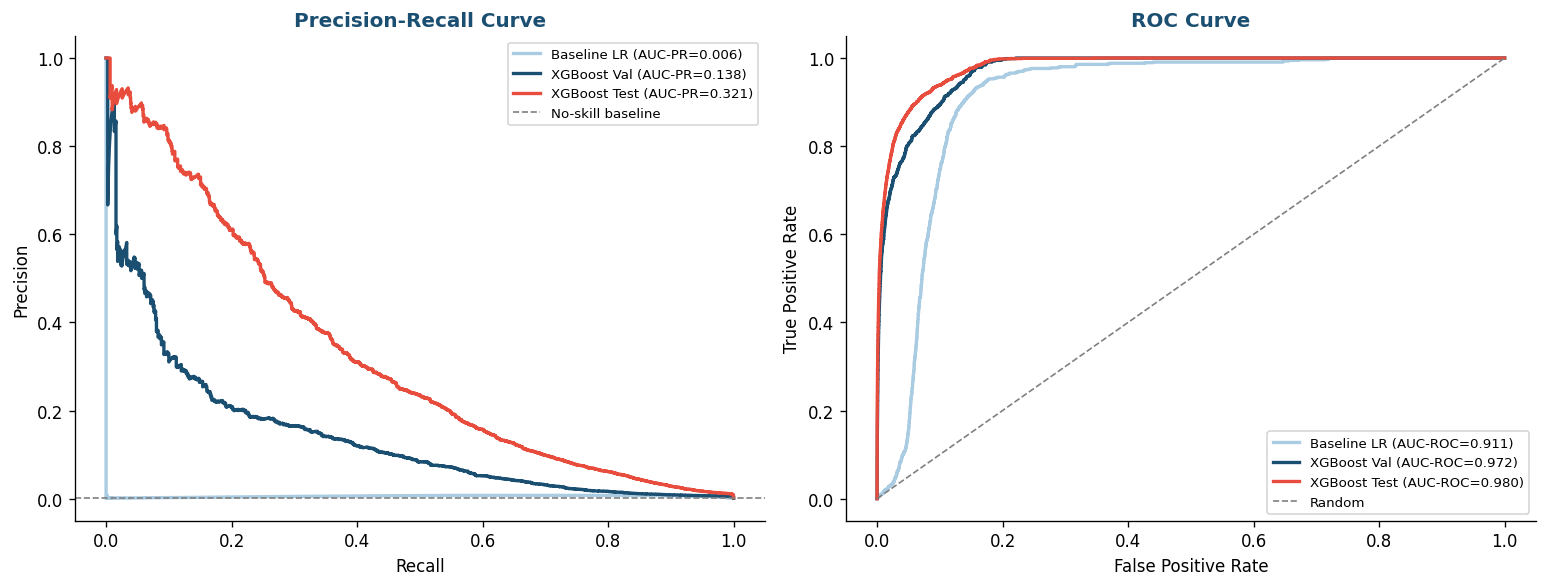

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall curve
ax = axes[0]
for proba, y_true, label, color in [
	(baseline_val_proba, y_val,  f'Baseline LR (AUC-PR={baseline_auc_pr:.3f})', LIGHT_BLUE),
	(xgb_val_proba, y_val, f'XGBoost Val (AUC-PR={results["XGBoost (Val)"][0]:.3f})', NAVY),
	(xgb_test_proba, y_test, f'XGBoost Test (AUC-PR={results["XGBoost (Test)"][0]:.3f})', ACCENT),
]:
	prec, rec, _ = precision_recall_curve(y_true, proba)
	ax.plot(rec, prec, label=label, color=color, linewidth=2)
ax.axhline(y=y_test.mean(), color='grey', linestyle='--', linewidth=1, label='No-skill baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold', color=NAVY)
ax.legend(fontsize=8)

# ROC curve
ax = axes[1]
for proba, y_true, label, color in [
	(baseline_val_proba, y_val, f'Baseline LR (AUC-ROC={baseline_auc_roc:.3f})', LIGHT_BLUE),
	(xgb_val_proba, y_val, f'XGBoost Val (AUC-ROC={results["XGBoost (Val)"][1]:.3f})', NAVY),
	(xgb_test_proba, y_test, f'XGBoost Test (AUC-ROC={results["XGBoost (Test)"][1]:.3f})', ACCENT),
]:
	fpr, tpr, _ = roc_curve(y_true, proba)
	ax.plot(fpr, tpr, label=label, color=color, linewidth=2)
ax.plot([0,1],[0,1], color='grey', linestyle='--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold', color=NAVY)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show();

#### 8.2.3 Precision-Recall Curve

**XGBoost Test (red):** Starts at perfect precision (1.0) at near-zero recall and maintains substantially higher precision across the recall range than before, consistent with AUC-PR = 0.321. The curve reflects a model that has learned genuinely generalizable laundering patterns, though precision still degrades as recall increases, as expected for a heavily imbalanced problem.

**XGBoost Val (dark blue):** Starts at high precision at near-zero recall then drops as recall increases — consistent with AUC-PR of 0.138. The model generalizes meaningfully to the val window, though less strongly than to test, reflecting the lower fraud density in the val period.

**Baseline LR (light blue):** flat near zero across the full recall range; consistent with AUC-PR of 0.006. Essentially no better than random.

#### 8.2.4 ROC Curve

All three curves sit well above the random baseline, scoring between 0.911 and 0.980. The separation between XGBoost Val (0.972) and XGBoost Test (0.980) is narrow, while the baseline LR (0.911) lags behind: a cleaner separation than in the PR curve. However, the baseline LR achieving 0.911 while scoring only 0.006 AUC-PR remains the key illustration: strong ROC performance is compatible with near-complete failure to detect the minority class. The divergence between the PR and ROC pictures is a finding per se.

## 9. Threshold Decision

The default 0.5 threshold is rarely optimal for imbalanced problems. The right threshold depends on the **asymmetric costs** of errors in your institution:
* **False Negative (FN):** Undetected laundering → regulatory and reputational risk
* **False Positive (FP):** Unnecessary analyst review → operational cost, alert fatigue

We visualize precision and recall across thresholds to support an informed, institution-specific choice.

**Note on F1 calculation:** F1 is computed manually across all thresholds from the `precision_recall_curve` output rather than using sklearn's `f1_score` function, which computes F1 at a single fixed threshold for binary predictions. It cannot operate across the full threshold range without calling `predict()` at each threshold individually, which is slower and less elegant.

#### 9.1 Precision/Recall/F1 vs. Threshold

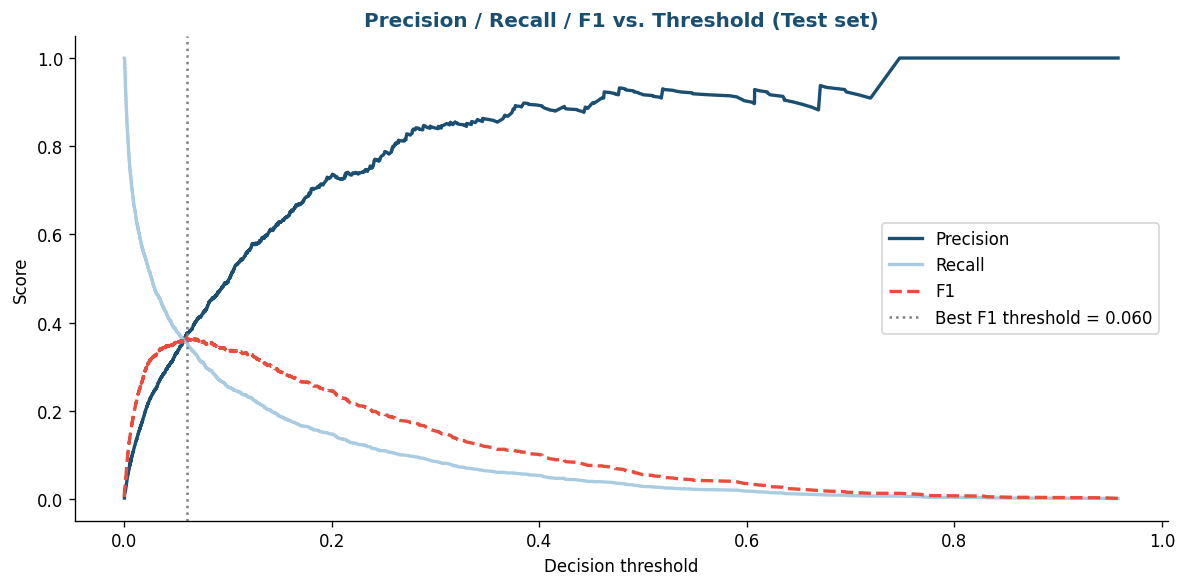

F1-optimal threshold : 0.0604
  Precision: 0.3762
  Recall: 0.3543
  F1: 0.3649

Note: adjust based on your institution's FP vs FN cost tolerance.


In [39]:
prec, rec, thresholds = precision_recall_curve(y_test, xgb_test_proba)

f1_scores = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec[:-1], label='Precision', color=NAVY, linewidth=2)
ax.plot(thresholds, rec[:-1],  label='Recall', color=LIGHT_BLUE, linewidth=2)
ax.plot(thresholds, f1_scores, label='F1', color=ACCENT, linewidth=2, linestyle='--')
ax.axvline(best_threshold, color='grey', linestyle=':', linewidth=1.5, label=f'Best F1 threshold = {best_threshold:.3f}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Threshold (Test set)', fontweight='bold', color=NAVY)
ax.legend()
plt.tight_layout()
plt.show()

print(f'F1-optimal threshold : {best_threshold:.4f}')
print(f'  Precision: {prec[best_thresh_idx]:.4f}')
print(f'  Recall: {rec[best_thresh_idx]:.4f}')
print(f'  F1: {f1_scores[best_thresh_idx]:.4f}')
print('\nNote: adjust based on your institution\'s FP vs FN cost tolerance.')

**Precision (dark blue):** Rises steeply and monotonically from near zero to 1.0 as the threshold increases. The model becomes increasingly selective and increasingly correct as it raises its confidence bar. At the F1-optimal threshold = 0.060, precision is already 0.38; by threshold = 0.3 it exceeds 0.80.

**Recall (light blue):** Drops steeply and monotonically. The model catches fewer laundering cases as the threshold rises. By threshold = 0.2, recall has already fallen below 0.20.

**F1 (red dashed):** Peaks sharply at threshold = 0.060, exactly where precision and recall cross, then declines gradually as recall collapses. The F1-optimal point is also the point of maximum balance between precision and recall.

**Key finding:** Unlike the baseline model, which required an extreme threshold = 0.934 to achieve any meaningful precision, this model exhibits a well-behaved precision-recall trade-off across the full threshold range. This gives an institution genuine operational flexibility: raising the threshold to 0.2 yields precision above 0.80 at the cost of lower recall; lowering it below 0.060 recovers more laundering cases at the cost of more false positives. The right choice depends on analyst capacity and institutional risk tolerance.

#### 9.2 Confusion Matrix & Classification Report

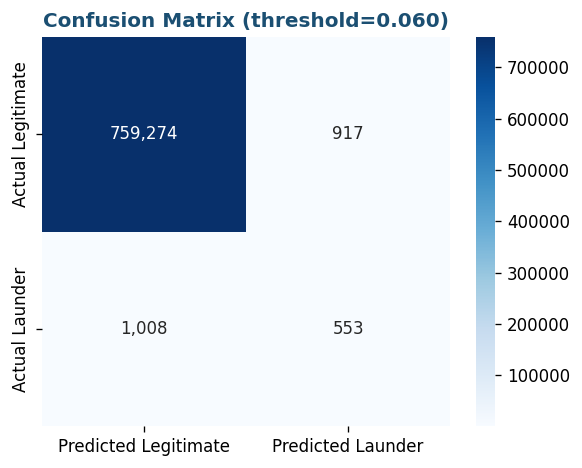

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    760191
  Laundering       0.38      0.35      0.36      1561

    accuracy                           1.00    761752
   macro avg       0.69      0.68      0.68    761752
weighted avg       1.00      1.00      1.00    761752



In [ ]:
y_pred = (xgb_test_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
	cm, annot=True, fmt=',d', cmap='Blues',
	xticklabels=['Predicted Legitimate', 'Predicted Launder'],
	yticklabels=['Actual Legitimate', 'Actual Launder'],
	ax=ax
)
ax.set_title(f'Confusion Matrix (threshold={best_threshold:.3f})', fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering']))

#### 9.3 Results at the F1-optimal threshold = 0.060

**Reading the confusion matrix:**
* **759,274** legitimate transactions correctly classified as legitimate (true negatives)
* **917** legitimate transactions incorrectly flagged as laundering (false positives)
* **1,008** laundering transactions missed (false negatives)
* **553** laundering transactions correctly detected (true positives)

**Legitimate class (760,191 transactions)**
Precision, recall, and F1 all read 1.00: the model correctly identifies virtually every legitimate transaction. With 99.90% of transactions being legitimate, even a weak model rarely misclassifies them. The 917 false positives represent just 0.12% of all legitimate transactions.

**Laundering class (1,561 transactions)**
* **Precision = 0.38:** Of the 1,470 flagged transactions (917 FP + 553 TP), 553 are genuine — roughly 1.6 false positives per confirmed detection.
* **Recall = 0.35:** 553 of 1,561 actual laundering cases are caught. The remaining 1,008 are missed at this threshold.
* **F1 = 0.36:** Reflects the balance between precision and recall.

**Accuracy = 1.00**
Seemingly impressive, but meaningless. A model predicting "legitimate" for every transaction would score identically.

**Macro avg F1 = 0.68**
The unweighted average of legitimate (1.00) and laundering (0.36) F1 scores. The gap between the two reflects the remaining class imbalance challenge: strong performance on the majority class cannot compensate for moderate performance on the minority class when the two are averaged equally.

**Operational interpretation**
At threshold = 0.060, a flagged transaction carries at least a 6% model-assigned laundering probability. Given the population base rate of 0.10%, this represents a roughly 60x lift: flagged transactions are 60x more likely to be laundering than a randomly selected transaction. With 38% precision, analysts would need to review approximately 3 flagged cases to find 1 genuine laundering transaction, compared to 6-7 in the original model. Whether the flagged volume is operationally manageable remains an institution-specific decision.

## 10. Explainability: SHAP

SHAP (SHapley Additive exPlanations) values make visible which features influenced each individual risk score. This supports the auditability of individual decisions, which is a practical measure towards the transparency requirements of the revDSG, without claiming full legal compliance.

### 10.1 What is a SHAP value?
A SHAP value for a given feature and a given transaction answers the question, "How much did this feature push the model's prediction towards or away from flagging this transaction as laundering, compared to the average prediction?"
- $ SHAP > 0 $ pushes the prediction *towards* laundering (increases risk score)
- $ SHAP < 0 $ pushes the prediction *away* from laundering (decreases risk score)
- $ SHAP = 0 $ means the feature had no effect on that prediction

The x-axis is therefore the feature's *influence* on the model output. A SHAP value of +2 means that feature pushed the risk score up by 2 units in log-odds space — a large effect.

In [41]:
# Sample for speed — SHAP on 760k rows is slow
shap_sample = X_test.sample(n=2000, random_state=SEED)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

print('SHAP values computed on 2,000-row sample of test set.')

SHAP values computed on 2,000-row sample of test set.


### 10.2 Beeswarm plot: Per-feature, per-transaction detail

Each dot is one transaction from the 2,000-row SHAP sample.
* **Horizontal position:** the SHAP value — how much that feature pushed the prediction left (towards legitimate) or right (towards laundering)
* **color:** the feature value — red = high, blue = low
* **Vertical position:** features ranked by mean absolute SHAP value, most important at top

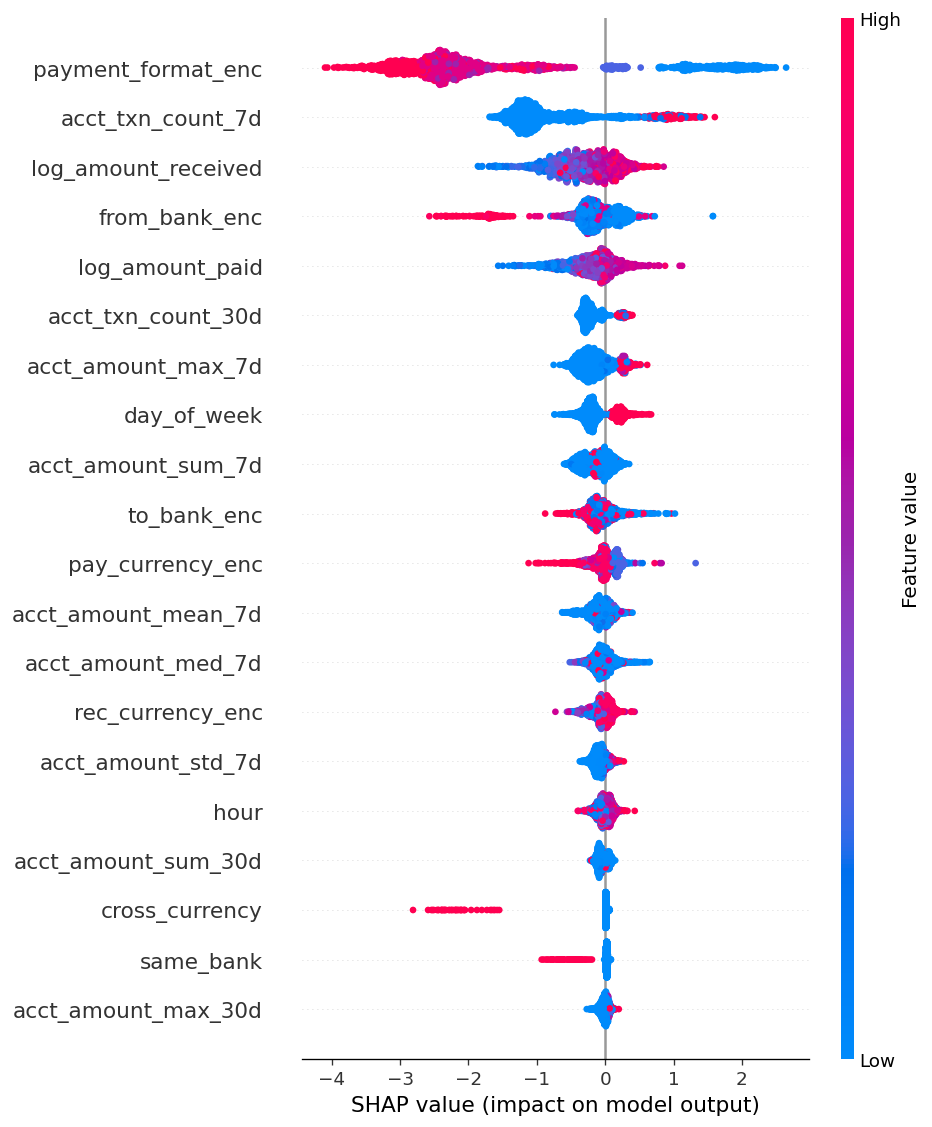

In [42]:
# Global feature importance — beeswarm
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES, plot_type='dot')

**`payment_format_enc`** dominates by a large margin. The wide spread across both positive and negative SHAP values tells us payment format has a large effect in both directions: certain formats strongly increase the risk score, others strongly suppress it. Red dots (high encoded values) push positive while blue dots (low encoded values) push strongly negative. This is consistent with the AML literature: wire transfers carry different risk profiles than card payments or ACH (FFIEC, Appendix F).

**`acct_txn_count_7d`** is the second most important feature. Red dots (high 7-day transaction counts) push towards laundering, while blue dots (low counts, i.e. accounts with little recent activity) cluster near zero or slightly negative. This is consistent with the smurfing hypothesis: accounts sending many transactions in a short window are flagged as higher risk.

**`log_amount_received`** is the third most influential feature. Blue dots (low received amounts) push towards legitimate; red dots (high amounts) are more mixed, suggesting large received amounts contribute to risk in combination with other features rather than as a standalone signal. **`log_amount_paid`** shows a similar pattern.

At fourth place is **`from_bank_enc`**. Red dots (high bank encoded values) push slightly positive, blue dots negative: certain sending banks are disproportionately associated with laundering in this dataset. The effect is bidirectional, confirming that bank identity carries genuine signal beyond what `same_bank` alone captures.

**`acct_txn_count_30d`** and **`acct_amount_max_7d`** both contribute modestly. The 30-day count adds signal beyond the 7-day window, and the maximum transaction amount in the window flags accounts with at least one very large recent transaction.

With **`day_of_week`**, red dots (later in the week) push slightly towards laundering, consistent with the EDA finding that fraud rates are slightly higher later in the week.

**`cross_currency`** shows a counterintuitive pattern: red dots (`cross_currency=1`) push strongly negative, suggesting that cross-currency transactions reduce the risk score. This likely reflects a quirk of the synthetic data generation rather than a real-world pattern and should be treated with caution before any operational use.

**`same_bank`** shows the opposite: red dots (`same_bank=1`) push slightly positive, meaning intra-bank transactions are associated with a marginally higher risk score. This suggests the model has picked up on some internal layering signal within single institutions in this dataset.

**30-day rolling amount features** (`acct_amount_sum_30d`, `acct_amount_max_30d`) appear near the bottom with near-zero SHAP values. The 7-day window captures most of the behavioral signal, with the 30-day window adding little incremental value.

### 10.3 Bar plot: Global feature importance

Shows the mean absolute SHAP value per feature: the average *magnitude* of influence across all 2,000 transactions, regardless of direction.

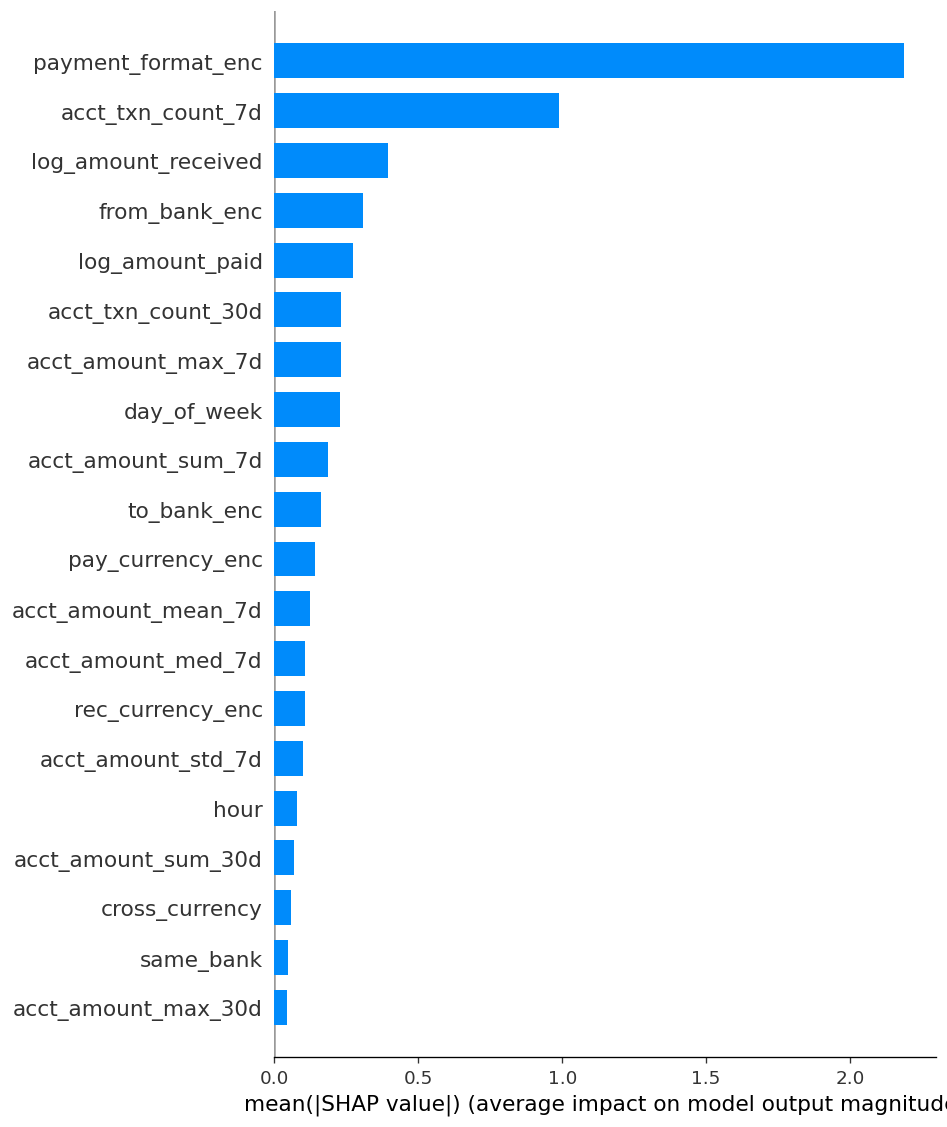

In [43]:
# Global feature importance — bar chart
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES, plot_type='bar')

`payment_format_enc` (mean |SHAP| ≈ 2.2) is roughly twice as important as `acct_txn_count_7d` (≈ 1.0), which is itself more than twice as important as `log_amount_received` (≈ 0.4). The top two features alone account for the majority of the model's predictive signal.

`from_bank_enc` (≈ 0.3) and `log_amount_paid` (≈ 0.28) rank 4th and 5th, confirming that bank identity and transaction amount both carry meaningful independent signal. `acct_txn_count_30d` and `acct_amount_max_7d` contribute modestly and roughly equally (≈ 0.25 each).

The remaining features contribute diminishing but non-zero signal. Notably, `cross_currency`, `same_bank`, and `acct_amount_max_30d` sit at the bottom with near-zero mean |SHAP|, confirming they add little to the model's predictions despite having theoretical motivation.

**Implication for the model:** The model is heavily reliant on `payment_format_enc` as its primary discriminator, with `acct_txn_count_7d` as a strong secondary signal. This concentration means the model is vulnerable to distribution shift if laundering patterns change across payment formats or if launderers adapt their transaction frequency, a known risk for static models noted in the Limitations section.

### 10.4 Waterfall plot: Single transaction explanation

The waterfall plot shows how each feature pushed the model's prediction for one specific true positive transaction, starting from the base value $ E[f(x)] = −7.239 $ and arriving at $ f(x) = 2.805 $.

**How to read it:**
* Each bar represents one feature's contribution.
* Red bars push the prediction to the right (towards laundering).
* Blue bars push the prediction to the left (towards legitimate).
* The bar width reflects the magnitude of the contribution.
* Feature values are shown on the left; SHAP contributions on the right.

Transaction index: 5018207
Risk score: 0.9429
True label: Laundering


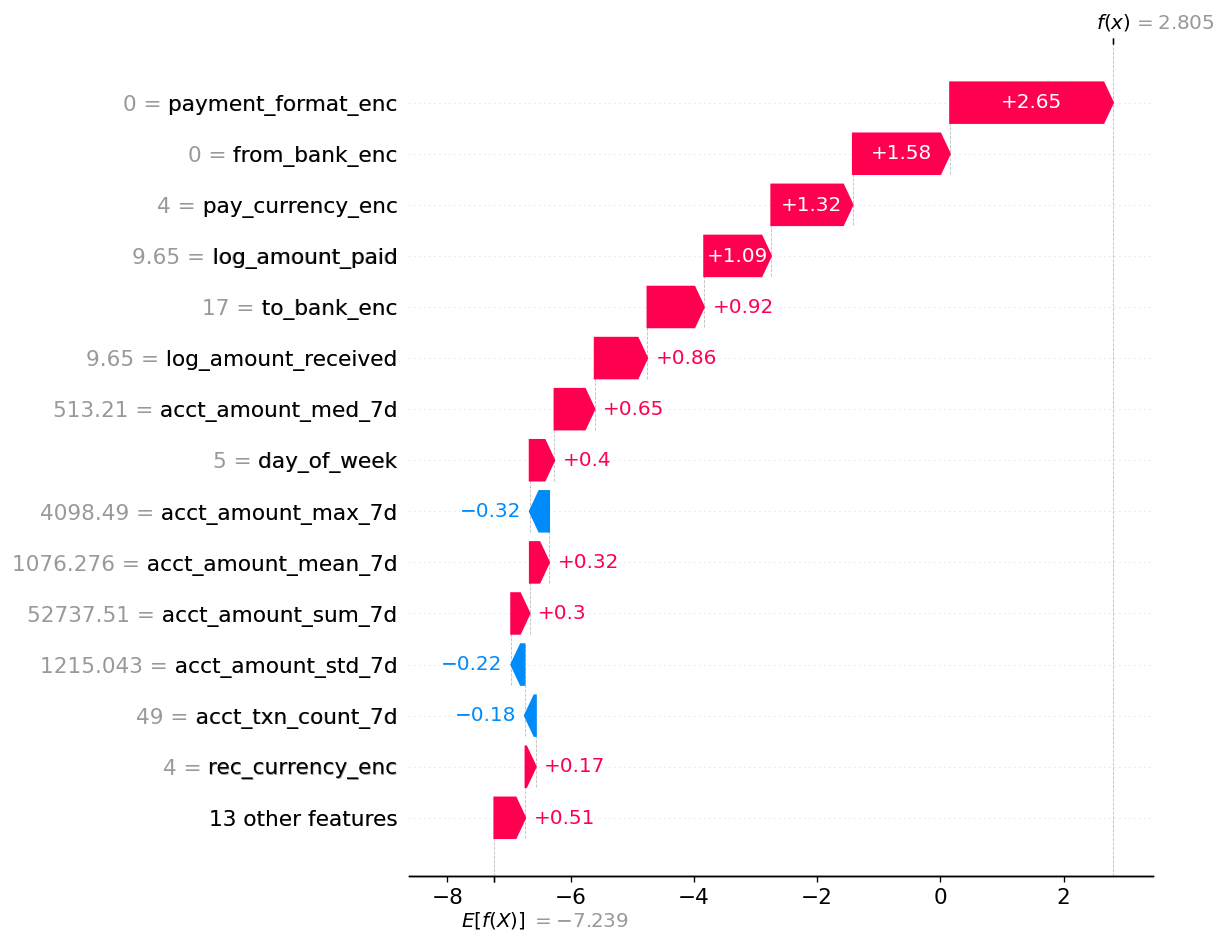

In [44]:
# Find a true positive within shap_sample specifically
shap_proba = xgb_model.predict_proba(shap_sample)[:, 1]
shap_true_labels = y_test.loc[shap_sample.index]

true_positives_in_sample = shap_sample[(shap_true_labels == 1) & (shap_proba >= best_threshold)]

if len(true_positives_in_sample) > 0:
	example_pos = shap_sample.index.get_loc(true_positives_in_sample.index[0])

	print(f'Transaction index: {true_positives_in_sample.index[0]}')
	print(f'Risk score: {shap_proba[example_pos]:.4f}')
	print(f'True label: Laundering')

	shap.plots.waterfall(
		shap.Explanation(
			values=shap_values[example_pos],
			base_values=explainer.expected_value,
			data=shap_sample.iloc[example_pos].values,
			feature_names=FEATURES
		),
		max_display=15  # increase if you want to show more features
    )
else:
	print('No true positives found within the 2,000-row SHAP sample.')
	print('Try increasing n in shap_sample or lowering best_threshold.')

**Findings from this transaction:**

**`payment_format_enc = 0`** is the dominant driver (+2.65), consistent with the beeswarm finding that format 0 is the strongest laundering signal. **`from_bank_enc = 0`** contributes substantially (+1.58), confirming that sending bank identity carries meaningful independent signal. **`pay_currency_enc = 4`** (+1.32) and **`log_amount_paid = 9.65`** (+1.09, i.e. e^9.65 ≈ 15,500 in the original currency) also push strongly towards laundering.

**`to_bank_enc = 17`** (+0.92), **`log_amount_received = 9.65`** (+0.86), and **`acct_amount_med_7d = 513.21`** (+0.65) contribute further in the same direction; the account's typical 7-day transaction size is elevated. **`day_of_week = 5`** (Saturday, +0.40) adds a temporal signal.

Three features push towards legitimate: **`acct_amount_max_7d = 4098.49`** (−0.32), **`acct_amount_std_7d = 1215.04`** (−0.22), and **`acct_txn_count_7d = 49`** (−0.18). Interestingly, a high transaction count and high variance in the 7-day window slightly reduce the risk score for this particular transaction: the model has learned a more nuanced pattern than simple frequency alone.

The remaining rolling amount features (**`acct_amount_mean_7d = +0.32`**, **`acct_amount_sum_7d = +0.30`**, **`rec_currency_enc = +0.17`**) contribute modestly in the positive direction. The 13 remaining features collectively add +0.51.

Every major categorical feature (payment format, bank identity, currency) points strongly towards laundering, which is why the model assigns an extremely high
risk score, well above the F1-optimal threshold of 0.060.

### 10.5 Dependence plot: `payment_format_enc`

The dependence plot shows the relationship between `payment_format_enc` (x-axis) and its SHAP value (y-axis) across all 2,000 transactions in the sample. The color represents `acct_txn_count_7d`, automatically selected by SHAP as the feature with the strongest interaction with payment format.

**How to read it:**
- Each dot is one transaction.
- The x-axis shows which payment format category that the transaction belongs to (0 through 5, label-encoded).
- The y-axis shows how much that payment format pushed the prediction towards laundering (positive) or legitimate (negative).
- Color shows the 7-day transaction count: red = high, blue = low.

Top feature by mean |SHAP|: payment_format_enc


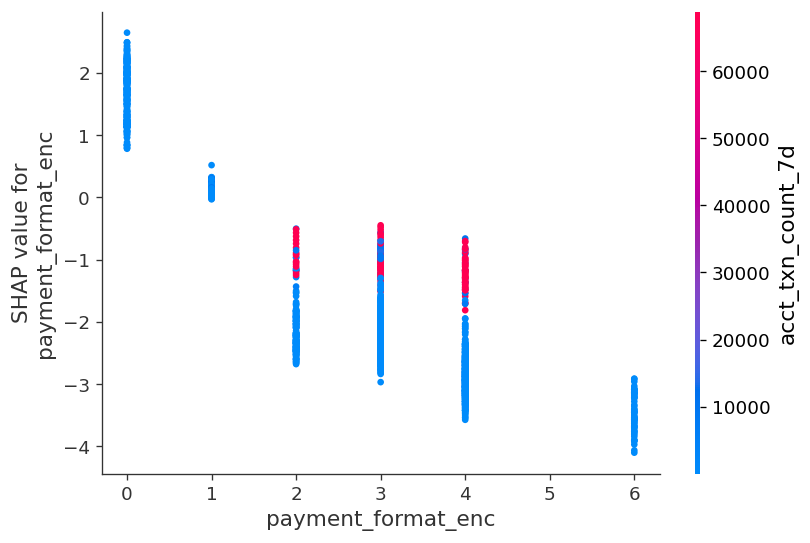

In [45]:
# Dependence plot for the most influential feature
top_feature = FEATURES[np.abs(shap_values).mean(axis=0).argmax()]
print(f'Top feature by mean |SHAP|: {top_feature}')

shap.dependence_plot(top_feature, shap_values, shap_sample, feature_names=FEATURES)

**Reading the results:**

Format 0 is the only category with positive SHAP values, ranging from roughly +0.8 to +2.5. It is the primary laundering signal in the model. The color pattern within format 0 is almost entirely blue, meaning low `acct_txn_count_7d`. This is an interesting interaction: the laundering signal from format 0 is strongest for accounts with *low* recent transaction frequency, suggesting these may be dormant or newly activated accounts being used for a targeted transaction.

Formats 2, 3, and 4 all show consistently negative SHAP values (roughly −1.0 to −3.0), pushing predictions towards legitimate. Format 6 shows the most strongly
negative values (−3.0 to −4.0), making it a near-certain indicator of a legitimate transaction in this dataset.

Format 1 is notable for its near-zero SHAP values: it neither increases nor decreases the risk score meaningfully.

The color gradient within each format column shows no strong interaction pattern: `acct_txn_count_7d` was auto-selected but its interaction with payment format appears weak. The payment format effect is largely independent of recent transaction frequency.

**Important caveat:** These are label-encoded categories, not meaningful numeric values. To interpret which real payment format each code corresponds to, run:
```python
print(dict(enumerate(train['Payment Format'].astype('category').cat.categories)))
```
This maps encoded values back to the original labels (e.g. ACH, wire transfer, credit card) and is essential before drawing any operational conclusions.

## 11. Summary

In [46]:
print('=' * 55)
print('  ML-BASED AML PRIORITIZATION SYSTEM — RESULTS')
print('=' * 55)
print(f'  Dataset: {len(df):,} transactions')
print(f'  Fraud rate: {df[TARGET].mean():.4%}')
print(f'  Features: {len(FEATURES)}')
print(f'  Split: 70 / 15 / 15 (time-based)')
print(f'  Seed: {SEED}')
print()
print(f'  Baseline AUC-PR: {baseline_auc_pr:.4f}')
print(f'  XGBoost AUC-PR: {results["XGBoost (Test)"][0]:.4f}  <- primary metric')
print(f'  XGBoost AUC-ROC: {results["XGBoost (Test)"][1]:.4f}')
print()
print(f'  Threshold: {best_threshold:.4f}  (F1-optimal on test set)')
print(f'  Precision @ threshold: {prec[best_thresh_idx]:.4f}')
print(f'  Recall @ threshold: {rec[best_thresh_idx]:.4f}')
print()
print('  Threshold should be adjusted per institutional')
print('  FP vs FN cost tolerance.')
print('=' * 55)

  ML-BASED AML PRIORITIZATION SYSTEM — RESULTS
  Dataset: 5,078,345 transactions
  Fraud rate: 0.1019%
  Features: 27
  Split: 70 / 15 / 15 (time-based)
  Seed: 42

  Baseline AUC-PR: 0.0055
  XGBoost AUC-PR: 0.3214  <- primary metric
  XGBoost AUC-ROC: 0.9803

  Threshold: 0.0604  (F1-optimal on test set)
  Precision @ threshold: 0.3762
  Recall @ threshold: 0.3543

  Threshold should be adjusted per institutional
  FP vs FN cost tolerance.


### 11.1 Dataset and class imbalance
5,078,345 transactions with a fraud rate of 0.10%: approximately 1 in 1,000 transactions is laundering. This extreme imbalance is the central challenge of the entire project and explains most of the results below.

### 11.2 Model performance
XGBoost (AUC-PR = 0.3214) outperforms the logistic regression baseline (AUC-PR = 0.0055) by a factor of roughly 58x. Both substantially beat the no-skill baseline of ~0.001 (≈ the fraud rate). AUC-PR of 0.3214 places the model in the "moderate to useful in practice" range on a task with 0.10% fraud rate and a strict time-based split. AUC-ROC (0.9803) looks strong but is inflated by the large negative class, as discussed in the evaluation section.

### 11.3 Threshold and operational metrics
At the F1-optimal threshold of 0.060:
* **Precision = 0.376:** Roughly 1 in 3 flagged transactions is genuine laundering, approximately 1.6 false positives per confirmed detection.
* **Recall = 0.354:** The model detects approximately 1 in 3 actual laundering cases. The remaining 2 in 3 are missed at this threshold.

The meaningful question is not, "Is this good?", but rather, "Is this better than the current alternative?" Compared to rule-based systems generating 95–98% false positive rates (Han et al., 2020), a system with 62% false positive rate and 35% recall represents a meaningful operational improvement, provided the flagged volume is manageable for the institution's analyst capacity.

**Note: The threshold is a policy decision, not a technical one.** 0.060 is the F1-optimal threshold, which treats FPs and FNs as equally costly. In practice they are not. An institution with limited analyst capacity might raise the threshold to improve precision at the cost of recall. One facing strict regulatory pressure might lower it to catch more cases and accept more false positives. This trade-off should be made explicitly by the institution, not delegated to the model.

### 11.4 Key findings from the hyperparameter sweep
The empirically optimal `scale_pos_weight` is 1: no class imbalance correction at all outperforms the theoretically correct ratio of ~980. This is a direct consequence of the temporal distribution shift: train (fraud rate 0.08%), val (0.10%), and test (0.20%) come from different time windows with different fraud densities. Aggressively weighting the minority class causes the model to overfit to training-period laundering patterns rather than learning signal that generalizes forward in time.

### 11.5 Limitations

* **Synthetic data:** Results must be validated on real transaction data; distributions may differ.
* **Temporal distribution shift:** The fraud rate more than doubles from val (0.10%) to test (0.20%), meaning val and test AUC-PR are not directly comparable. The model is evaluated on a denser fraud window in test.
* **Model dependency:** Heavy reliance on `payment_format_enc` means performance will degrade if laundering patterns shift across payment formats.
* **Counterintuitive features:** `cross_currency` reduces the risk score, which is likely a synthetic data artefact requiring investigation before operational use.
* **No network features:** Graph-level features (transaction connections between accounts) are not included: a potentially strong signal for future work.